In [1]:
import time
import warnings
from io import StringIO
from pathlib import Path
from datetime import datetime, timedelta
from typing import List, Optional, Tuple

import pandas as pd
import requests
import yfinance as yf

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

from sklearn.covariance import LedoitWolf
from scipy.linalg import cho_factor, cho_solve

__Cleaning the Universe__

In [2]:
# =============================================================================
# UNIVERSE SELECTION -- Cell 1 / 4 : load everything that was downloaded
# =============================================================================
# Step 1 of the data pipeline (`01_download_data.py`) already fetched ~5 years
# of split/dividend-adjusted daily closes and raw share volumes for every
# current S&P 500 constituent, and cached them as two wide parquet tables
# (rows = trading days, columns = tickers). Here we just load them back in and
# look at what we actually have, BEFORE any filtering -- that way every later
# filter can be reported as "X names in, Y names out".
#
# We deliberately load the FULL downloaded history (not just the window we
# intend to analyse) because the completeness filter in cell 2 is more
# informative over the long window: a stock that IPO'd or was added to the
# index two years ago looks perfectly clean in a 1000-day window but is
# clearly incomplete over 5 years, and those late arrivals are exactly the
# names whose data is most likely to have oddities.

OUTPUT_DIR = Path("output")          # created by 01_download_data.py

# --- configuration for the whole universe-selection procedure -----------------
ANALYSIS_END   = "2026-07-23"   # last trading day of the estimation sample.
                                # Chosen by hand: the raw download runs a few
                                # days past this, but those trailing rows are
                                # not trustworthy (see the NaN-per-row printout
                                # below), so we cut the sample here.
T_RETURNS      = 1000           # number of *return* observations we require,
                                # i.e. T in q = N/T. Needs T_RETURNS + 1
                                # consecutive price rows.
N_TARGET       = 300            # final universe size, i.e. N in q = N/T.
MIN_COMPLETENESS = 0.99         # cell 2: drop a ticker if more than 1% of its
                                # full-history prices are missing.
MAX_CORR       = 0.98           # cell 3: pairs above this are treated as the
                                # same security, not as economic structure.

# --- load ---------------------------------------------------------------------
prices_all  = pd.read_parquet(OUTPUT_DIR / "prices_full_history.parquet")
volumes_all = pd.read_parquet(OUTPUT_DIR / "volumes_full_history.parquet")

# Defensive check: the two tables must be aligned on both axes, otherwise the
# dollar-volume product in cell 2 would silently pair up the wrong columns.
prices_all, volumes_all = prices_all.align(volumes_all, join="inner")

print(f"Loaded prices : {prices_all.shape[0]} trading days x {prices_all.shape[1]} tickers")
print(f"Loaded volumes: {volumes_all.shape[0]} trading days x {volumes_all.shape[1]} tickers")
print(f"Date range    : {prices_all.index.min().date()} -> {prices_all.index.max().date()}")
print(f"Duplicate dates in index: {prices_all.index.duplicated().sum()}")
print(f"Total missing prices: {prices_all.isna().sum().sum():,} "
      f"({100 * prices_all.isna().mean().mean():.2f}% of all cells)")

# --- where are the missing values? --------------------------------------------
# Missing values come in two very different flavours and it matters which:
#   * missing down a COLUMN  -> that ticker has a short history (recent IPO,
#     recent index addition). Handled by the completeness filter in cell 2.
#   * missing across a ROW   -> that whole *date* is broken in the data feed.
#     One bad row would inject a fake NaN into every single stock and destroy
#     the "1000 consecutive clean days" requirement for the entire universe,
#     so these have to be spotted and cut, not filtered per-ticker.
nan_per_row = prices_all.isna().sum(axis=1)
bad_rows = nan_per_row[nan_per_row > 0.5 * prices_all.shape[1]]
print(f"\nDates where >50% of tickers are missing (broken feed rows): {len(bad_rows)}")
for d, n in bad_rows.items():
    print(f"   {d.date()}: {n} / {prices_all.shape[1]} tickers missing")

print(f"\nLast 6 rows, missing count per row "
      f"(sanity check on the ANALYSIS_END = {ANALYSIS_END} choice):")
print(nan_per_row.tail(6).to_string())

# --- worst offenders by column ------------------------------------------------
completeness_all = prices_all.notna().mean()
print("\n10 least complete tickers over the full history "
      "(fraction of days with a real price):")
print(completeness_all.sort_values().head(10).to_string(float_format="%.3f"))

Loaded prices : 1275 trading days x 502 tickers
Loaded volumes: 1275 trading days x 502 tickers
Date range    : 2021-06-28 -> 2026-07-27
Duplicate dates in index: 0
Total missing prices: 7,934 (1.24% of all cells)

Dates where >50% of tickers are missing (broken feed rows): 1
   2026-07-24: 501 / 502 tickers missing

Last 6 rows, missing count per row (sanity check on the ANALYSIS_END = 2026-07-23 choice):
Date
2026-07-20      0
2026-07-21      0
2026-07-22      0
2026-07-23      0
2026-07-24    501
2026-07-27      0

10 least complete tickers over the full history (fraction of days with a real price):
HONA   0.022
FDXF   0.032
Q      0.146
SNDK   0.284
GEV    0.457
SOLV   0.458
VLTO   0.551
KVUE   0.634
GEHC   0.708
CEG    0.888


In [3]:
# =============================================================================
# UNIVERSE SELECTION -- Cell 2 / 4 : quality filters (completeness, liquidity)
# =============================================================================
# Two filters, for two different reasons:
#
# COMPLETENESS. A covariance matrix needs the *same* T days for every stock:
# the whole point of q = N/T is that it counts one common sample size. Stocks
# with short or gappy histories force either dropping days (shrinking T for
# everyone) or filling gaps (inventing data, which biases correlations toward
# zero and quietly flatters every "cleaned" estimator). Cheaper to drop the
# stock. Threshold: >99% of the full downloaded history must be real prices.
#
# LIQUIDITY. Thinly traded stocks have stale prices: if a stock does not trade
# near the close, its recorded close is an old price, so its return appears on
# the wrong day. That mechanically *understates* its correlation with everything
# else (the "Epps effect") -- a real bias in the object we are trying to
# estimate, not just extra noise. Ranking by average dollar volume
# (price x shares traded) and keeping the top names is the standard fix, and is
# what the CFM/RMT papers do for the same reason. Dollar volume is also the
# right tie-breaker in cell 3, where we must choose which of two nearly
# identical stocks to keep.
#
# Note we RANK by liquidity here but do not yet cut to N_TARGET: cell 3 still
# has to remove duplicate securities, and cell 4 imposes the strict "no gaps in
# the estimation window" rule. Cutting to exactly 300 only makes sense once
# both of those have had their say.

# The liquidity ranking is computed over the estimation window we will actually
# use (not the full 5 years), because what matters is how tradeable / how
# well-priced each name is during the sample we estimate the covariance from.
liq_window = slice(None, ANALYSIS_END)
px_win  = prices_all.loc[liq_window].tail(T_RETURNS + 1)
vol_win = volumes_all.loc[liq_window].tail(T_RETURNS + 1)

# --- filter 1: completeness over the FULL downloaded history ------------------
completeness = prices_all.notna().mean()
passes_completeness = completeness >= MIN_COMPLETENESS

# --- filter 2 (ranking, not yet a cut): average dollar volume -----------------
# price * volume, averaged over the estimation window. In dollars/day.
avg_dollar_volume = (px_win * vol_win).mean()

quality = pd.DataFrame({
    "completeness": completeness,
    "avg_dollar_volume": avg_dollar_volume,
    "passes_completeness": passes_completeness,
})

n_before = len(quality)
dropped_incomplete = quality.index[~quality["passes_completeness"]].tolist()

# Survivors, sorted most liquid first. This ordering is carried through cells
# 3 and 4 -- "top N" always means "top N by average dollar volume".
filtered = (quality[quality["passes_completeness"]]
            .sort_values("avg_dollar_volume", ascending=False))

print(f"Completeness filter (>= {MIN_COMPLETENESS:.0%} of full history):")
print(f"   in : {n_before} tickers")
print(f"   out: {len(filtered)} tickers  ({len(dropped_incomplete)} dropped)")
print(f"   dropped: {dropped_incomplete}")

print(f"\nLiquidity ranking over {px_win.index[0].date()} -> {px_win.index[-1].date()} "
      f"({len(px_win)} price rows):")
print("\n   most liquid 10 ($bn/day):")
print((filtered["avg_dollar_volume"].head(10) / 1e9).to_string(float_format="%.2f"))
print("\n   least liquid 10 ($mn/day):")
print((filtered["avg_dollar_volume"].tail(10) / 1e6).to_string(float_format="%.1f"))

# Is the N_TARGET cut going to bite in a place where liquidity is still
# comfortable? If the 300th name trades a few hundred million a day we are fine;
# if it trades a few million we have a staleness problem regardless of ranking.
if len(filtered) >= N_TARGET:
    cutoff = filtered["avg_dollar_volume"].iloc[N_TARGET - 1]
    print(f"\nLiquidity at rank {N_TARGET} (provisional cutoff): "
          f"${cutoff/1e6:,.0f}mn/day")
else:
    print(f"\nWARNING: only {len(filtered)} tickers survive, fewer than "
          f"N_TARGET = {N_TARGET}. Loosen MIN_COMPLETENESS or lower N_TARGET.")

Completeness filter (>= 99% of full history):
   in : 502 tickers
   out: 491 tickers  (11 dropped)
   dropped: ['CEG', 'FDXF', 'GEHC', 'GEV', 'HONA', 'KVUE', 'Q', 'HOOD', 'SNDK', 'SOLV', 'VLTO']

Liquidity ranking over 2022-07-27 -> 2026-07-23 (1001 price rows):

   most liquid 10 ($bn/day):
NVDA    27.28
TSLA    26.59
AAPL    11.79
MSFT     9.60
AMZN     8.49
AMD      7.95
META     7.85
MU       5.90
GOOGL    5.81
AVGO     4.92

   least liquid 10 ($mn/day):
AOS    79.8
NWSA   75.5
AIZ    71.2
REG    69.6
NDSN   68.9
FRT    64.1
L      61.6
FOX    53.3
ERIE   44.7
NWS    24.8

Liquidity at rank 300 (provisional cutoff): $225mn/day


In [4]:
# =============================================================================
# UNIVERSE SELECTION -- Cell 3 / 4 : remove duplicated securities
# =============================================================================
# We now look for pairs of "different" stocks that are in fact the same asset.
# The classic cases are dual share classes (GOOGL / GOOG, FOXA / FOX, NWSA /
# NWS): same company, same cash flows, two listings, so their daily returns
# agree to within a rounding error.
#
# WHY THIS MATTERS FOR THIS PROJECT SPECIFICALLY. A pair with rho = 0.998
# creates an eigenvector -- the long/short spread between the two share
# classes -- with eigenvalue ~ 1 - rho ~ 0.002, i.e. essentially zero. Three
# things then break:
#   * the correlation matrix becomes near-singular, so Sigma^-1 in the GMV
#     weights w ~ Sigma^-1 1 blows up and the portfolio piles into a huge
#     offsetting long/short bet on one pair of share classes;
#   * that near-zero eigenvalue sits far below the Marchenko-Pastur left edge
#     (1 - sqrt(q))^2, so it is not noise the RMT machinery is designed to
#     clean -- it is a genuine (but useless) rank deficiency, and it drags the
#     RIE's kappa calibration around (see `RIE_failure_mode_note.md`);
#   * the comparison between estimators ends up being decided by an artefact
#     rather than by how well each method handles noise.
#
# THRESHOLD CHOICE. 0.98 on daily returns is deliberately extreme. Genuine
# industry structure -- MA/V, HD/LOW, AMAT/LRCX/KLAC, the apartment REITs --
# lives at 0.80-0.93 and is exactly the correlation structure this project is
# meant to ESTIMATE, so it must be left alone. Only "this is literally the same
# security twice" clears 0.98. Do NOT lower this threshold to tidy up the
# spectrum: an earlier version of this project pruned 30 names that way and
# destroyed the signal.
#
# WHICH ONE TO KEEP. The more liquid share class, using the dollar-volume
# ranking from cell 2. For dual listings the liquid class is the one with the
# real price discovery; the other one is likelier to be stale.

candidates = filtered.index.tolist()          # already sorted by liquidity desc

# Returns over the estimation window. Simple returns (P_t / P_{t-1} - 1), for
# consistency with the rest of the pipeline; at daily frequency log and simple
# returns give correlations that agree to ~1e-4, so this choice is immaterial
# here. `.dropna(how="all")` just removes the first row, which is NaN by
# construction.
ret_win = px_win[candidates].pct_change().dropna(how="all")

# Pairwise correlation. pandas uses pairwise-complete observations, so the few
# remaining scattered NaNs (each ticker still has up to 1% of them) do not
# propagate; cell 4 removes them properly.
corr = ret_win.corr()

# Extract the upper triangle as a long list of pairs, sorted most correlated
# first. np.triu_indices(N, 1) gives (i, j) with i < j, i.e. each pair once and
# no diagonal.
i_idx, j_idx = np.triu_indices(len(candidates), k=1)
pair_corr = pd.DataFrame({
    "a": [candidates[i] for i in i_idx],
    "b": [candidates[j] for j in j_idx],
    "corr": corr.values[i_idx, j_idx],
}).sort_values("corr", ascending=False, ignore_index=True)

print(f"Pairwise correlations of daily returns over "
      f"{ret_win.index[0].date()} -> {ret_win.index[-1].date()} "
      f"({len(ret_win)} returns, {len(candidates)} tickers, "
      f"{len(pair_corr):,} pairs)\n")

print("Counts above each threshold:")
for th in (0.99, MAX_CORR, 0.95, 0.90, 0.85):
    print(f"   |rho| > {th:.2f}: {(pair_corr['corr'] > th).sum():>6,} pairs")

print("\nTop 15 pairs (for context -- only those above the threshold are cut):")
for _, row in pair_corr.head(15).iterrows():
    a, b = row["a"], row["b"]
    mark = "  <-- DUPLICATE, will cut" if row["corr"] > MAX_CORR else ""
    print(f"   {a:6s} / {b:6s}  rho = {row['corr']:+.4f}   "
          f"$/day {filtered.loc[a,'avg_dollar_volume']/1e6:>8,.0f}mn vs "
          f"{filtered.loc[b,'avg_dollar_volume']/1e6:>8,.0f}mn{mark}")

# --- do the elimination -------------------------------------------------------
# Walk the offending pairs from most to least correlated and drop the less
# liquid member. Walking a list of pairs (rather than doing it in one shot)
# handles clusters correctly: if A-B, A-C and B-C are all above the threshold,
# this keeps only the single most liquid of the three, because once B is
# dropped the B-C pair is already resolved.
offenders = pair_corr[pair_corr["corr"] > MAX_CORR]
dropped_duplicates = []
for _, row in offenders.iterrows():
    a, b = row["a"], row["b"]
    if a in dropped_duplicates or b in dropped_duplicates:
        continue                                    # cluster already resolved
    # `filtered` is sorted by liquidity, so the one appearing later is the
    # less liquid of the two.
    loser = b if filtered.index.get_loc(a) < filtered.index.get_loc(b) else a
    keeper = a if loser == b else b
    dropped_duplicates.append(loser)
    print(f"\n   rho({a}, {b}) = {row['corr']:.4f} > {MAX_CORR}: "
          f"keeping {keeper} (more liquid), dropping {loser}")

deduped = filtered.drop(index=dropped_duplicates)
print(f"\nDuplicate filter: {len(filtered)} -> {len(deduped)} tickers "
      f"({len(dropped_duplicates)} dropped: {dropped_duplicates})")

# Worth knowing about, even though we are not cutting them: pairs just under
# the threshold. If one of these turns out to be another share-class pair, it
# is a judgement call whether to raise or lower MAX_CORR -- but the decision
# should be made by looking at the names, not at the spectrum.
near_miss = pair_corr[(pair_corr["corr"] <= MAX_CORR) & (pair_corr["corr"] > 0.95)]
if len(near_miss):
    print(f"\nJust below the threshold (0.95 < rho <= {MAX_CORR}) -- "
          f"kept, but check whether these are share classes too:")
    for _, row in near_miss.iterrows():
        print(f"   {row['a']:6s} / {row['b']:6s}  rho = {row['corr']:+.4f}")

C:\Users\nikol\AppData\Local\Temp\ipykernel_32008\468392349.py:42: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_win = px_win[candidates].pct_change().dropna(how="all")


Pairwise correlations of daily returns over 2022-07-28 -> 2026-07-23 (1000 returns, 491 tickers, 120,295 pairs)

Counts above each threshold:
   |rho| > 0.99:      1 pairs
   |rho| > 0.98:      2 pairs
   |rho| > 0.95:      3 pairs
   |rho| > 0.90:     12 pairs
   |rho| > 0.85:     57 pairs

Top 15 pairs (for context -- only those above the threshold are cut):
   GOOGL  / GOOG    rho = +0.9975   $/day    5,805mn vs    4,068mn  <-- DUPLICATE, will cut
   FOXA   / FOX     rho = +0.9869   $/day      159mn vs       53mn  <-- DUPLICATE, will cut
   NWSA   / NWS     rho = +0.9722   $/day       76mn vs       25mn
   AVB    / EQR     rho = +0.9296   $/day      145mn vs      123mn
   MAA    / CPT     rho = +0.9182   $/day      107mn vs       99mn
   AMAT   / LRCX    rho = +0.9102   $/day    1,420mn vs    1,218mn
   EQR    / UDR     rho = +0.9090   $/day      123mn vs       96mn
   MLM    / VMC     rho = +0.9053   $/day      220mn vs      218mn
   DHI    / LEN     rho = +0.9047   $/day      383m

In [5]:
# =============================================================================
# UNIVERSE SELECTION -- Cell 4 / 4 : final cut to N x T with no gaps
# =============================================================================
# The estimators being compared (sample covariance, Ledoit-Wolf, RIE) all take
# a single rectangular T x N return matrix with no holes: they are functions of
# the eigenvalues of E = (1/T) Z^T Z, and that object is only defined if every
# stock has a return on every one of the same T days. So the last step is
# strict, not statistical:
#
#   1. take the block of T_RETURNS + 1 consecutive trading days ending at
#      ANALYSIS_END (T + 1 prices -> exactly T returns, so T in q = N/T is
#      exactly T_RETURNS -- easy to get off by one here);
#   2. keep only tickers with ZERO missing prices in that block (the ~1% of
#      missing values still tolerated by cell 2 is not tolerable here);
#   3. of those, take the top N_TARGET by the liquidity ranking from cell 2.
#
# Order matters: completeness is a hard constraint and liquidity is a
# preference, so the hard constraint is applied first and the ranking only
# breaks ties among the names that already qualify.

# --- step 1: the exact price block --------------------------------------------
px_block = prices_all.loc[:ANALYSIS_END].tail(T_RETURNS + 1)

if len(px_block) < T_RETURNS + 1:
    raise ValueError(
        f"Only {len(px_block)} trading days available up to {ANALYSIS_END}, "
        f"need {T_RETURNS + 1}. Download more history or lower T_RETURNS.")

print(f"Estimation block: {px_block.index[0].date()} -> {px_block.index[-1].date()}")
print(f"   {len(px_block)} price rows -> {len(px_block) - 1} return observations (T)")

# --- step 2: zero missing values in the block ---------------------------------
block = px_block[deduped.index]
fully_complete = block.columns[block.notna().all()]
print(f"\nZero-gap filter inside the block: "
      f"{len(deduped)} -> {len(fully_complete)} tickers")
dropped_gaps = [t for t in deduped.index if t not in set(fully_complete)]
if dropped_gaps:
    gap_counts = block[dropped_gaps].isna().sum().sort_values(ascending=False)
    print(f"   dropped (missing days in block): "
          f"{[f'{t}({n})' for t, n in gap_counts.items()]}")

# --- step 3: top N_TARGET by liquidity ----------------------------------------
eligible = deduped.loc[fully_complete]                # keeps liquidity order
if len(eligible) < N_TARGET:
    raise ValueError(
        f"Only {len(eligible)} eligible tickers, need {N_TARGET}. "
        f"Loosen MIN_COMPLETENESS / MAX_CORR, or lower N_TARGET.")

universe = eligible.head(N_TARGET).index.tolist()

print(f"\nFinal cut: top {N_TARGET} of {len(eligible)} eligible names by liquidity")
print(f"   liquidity range: ${eligible['avg_dollar_volume'].iloc[0]/1e9:,.1f}bn/day "
      f"({universe[0]}) down to "
      f"${eligible['avg_dollar_volume'].iloc[N_TARGET-1]/1e6:,.0f}mn/day "
      f"({universe[-1]})")

# --- build the final price / return matrices ----------------------------------
prices  = px_block[universe]
returns = prices.pct_change().dropna(how="all")      # T x N, no NaNs

N, T = returns.shape[1], returns.shape[0]
print(f"\nReturn matrix R: T = {T} days x N = {N} stocks,  q = N/T = {N/T:.4f}")

# --- final assertions ---------------------------------------------------------
# Cheap, but these are exactly the failure modes that would otherwise show up
# 200 lines later as a mysterious negative eigenvalue.
assert returns.isna().sum().sum() == 0, "NaNs survived into the return matrix"
assert not returns.index.duplicated().any(), "duplicate dates"
assert returns.shape == (T_RETURNS, N_TARGET), \
    f"expected ({T_RETURNS}, {N_TARGET}), got {returns.shape}"
assert (returns.std() > 0).all(), "a stock has zero variance over the window"
print("Assertions passed: no NaNs, no duplicate dates, correct shape, no zero-variance names.")

# Extreme daily moves are worth a look but NOT auto-removed: a -40% day is
# usually a real earnings shock, occasionally a botched split adjustment. Only
# the second kind should be fixed, and only by looking.
extreme = returns.abs() > 0.35
if extreme.any().any():
    print(f"\n{int(extreme.sum().sum())} single-day |return| > 35% "
          f"(flagged for inspection, not removed):")
    for (date, ticker), val in returns.where(extreme).stack().dropna().items():
        print(f"   {ticker:6s} {date.date()}  {val:+.1%}")

# --- persist ------------------------------------------------------------------
# Saved under new filenames so the step-1 outputs stay untouched, and so every
# later notebook cell can be re-run from disk without redoing this selection.
prices.to_parquet(OUTPUT_DIR / "prices_universe.parquet")
returns.to_parquet(OUTPUT_DIR / "returns_universe.parquet")
(OUTPUT_DIR / "universe.txt").write_text("\n".join(universe))
selection_report = quality.assign(
    dropped_incomplete=quality.index.isin(dropped_incomplete),
    dropped_duplicate=quality.index.isin(dropped_duplicates),
    dropped_gap_in_block=quality.index.isin(dropped_gaps),
    in_final_universe=quality.index.isin(universe),
).sort_values("avg_dollar_volume", ascending=False)
selection_report.to_csv(OUTPUT_DIR / "universe_selection_report.csv")

print(f"\nSaved -> {OUTPUT_DIR}/prices_universe.parquet, returns_universe.parquet, "
      f"universe.txt, universe_selection_report.csv")
print(f"\nFirst 20 of the final universe: {universe[:20]}")

# `returns` (T x N, no NaNs) is the object every later step consumes -- the same
# `R` used by the covariance / Ledoit-Wolf / RIE cells.
R = returns

Estimation block: 2022-07-27 -> 2026-07-23
   1001 price rows -> 1000 return observations (T)

Zero-gap filter inside the block: 489 -> 488 tickers
   dropped (missing days in block): ['FISV(1)']

Final cut: top 300 of 488 eligible names by liquidity
   liquidity range: $27.3bn/day (NVDA) down to $223mn/day (TPR)

Return matrix R: T = 1000 days x N = 300 stocks,  q = N/T = 0.3000
Assertions passed: no NaNs, no duplicate dates, correct shape, no zero-variance names.

15 single-day |return| > 35% (flagged for inspection, not removed):
   CVNA   2022-08-05  +40.1%
   TTD    2022-08-10  +36.2%
   BIIB   2022-09-28  +39.9%
   CVNA   2022-11-04  -39.0%
   CVNA   2022-12-07  -42.9%
   CVNA   2023-01-12  +46.0%
   CVNA   2023-06-08  +56.0%
   CVNA   2023-07-19  +40.2%
   SMCI   2024-01-19  +35.9%
   DXCM   2024-07-26  -40.7%
   APP    2024-11-07  +46.3%
   CNC    2025-07-02  -40.4%
   TTD    2025-08-08  -38.6%
   ORCL   2025-09-10  +35.9%
   SNPS   2025-09-10  -35.8%

Saved -> output/prices_un

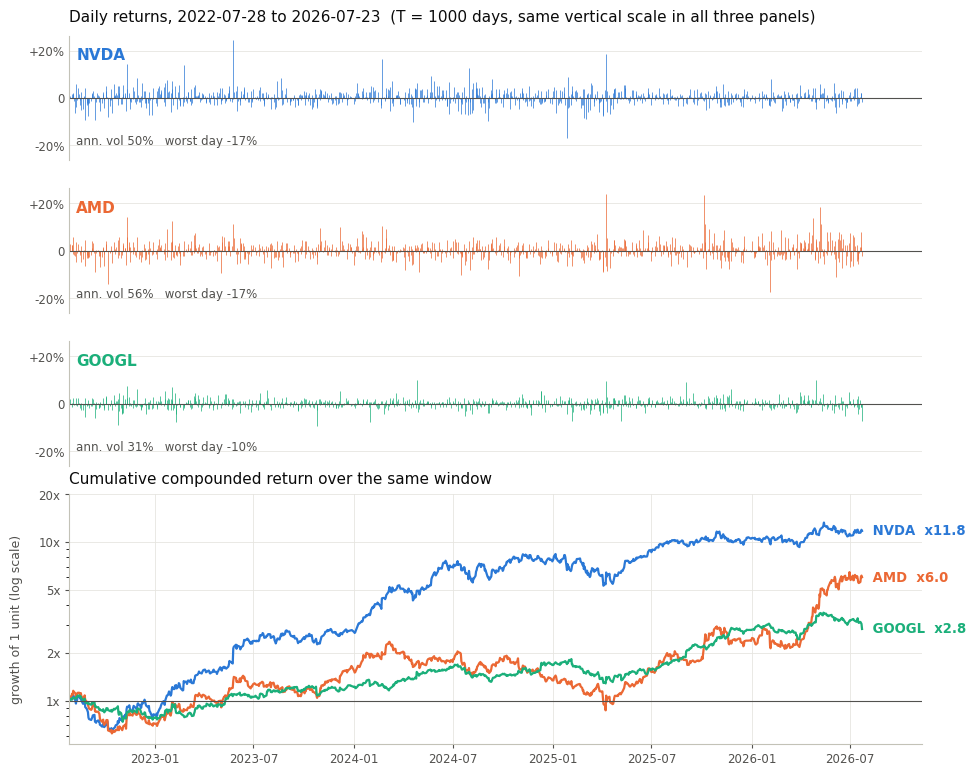

Summary over the estimation window:
       ann. vol  ann. mean  min day  max day    total
NVDA     +49.8%     +74.4%   -17.0%   +24.4% +1076.7%
AMD      +56.2%     +60.8%   -17.3%   +23.8%  +500.9%
GOOGL    +31.5%     +31.2%    -9.5%   +10.2%  +183.5%

Pairwise correlation of daily returns:
       NVDA   AMD  GOOGL
NVDA  1.000 0.611  0.434
AMD   0.611 1.000  0.431
GOOGL 0.434 0.431  1.000

For scale, the universe-wide average pairwise correlation is 0.232 -- so NVDA/AMD is far above typical, GOOGL/NVDA only moderately so.


In [6]:
# =============================================================================
# UNIVERSE SELECTION -- Cell 5 : eyeball the returns of a few names
# =============================================================================
# Before any covariance estimation, look at the raw input. Three names chosen to
# span the volatility range of the universe: NVDA and AMD are high-vol
# semiconductor names that also happen to be strongly correlated with each other
# (same industry, same AI-capex story), GOOGL is a lower-vol mega-cap from a
# different sector. So this is also a first visual check that the correlation
# structure we are about to estimate is really there.
#
# TWO KINDS OF PANEL, NOT ONE OVERLAY. Overlaying three daily-return series on
# one axis is unreadable -- 1000 points x 3 series of mean-zero noise just paints
# over itself, and the series drawn last looks the most volatile purely because
# it is on top. So:
#   * top: one small panel per stock, all sharing the SAME y-axis, so the
#     difference in volatility is directly visible as the width of the band
#     (this is the whole point of sharing the axis -- with per-panel autoscaling
#     every stock would look equally volatile);
#   * bottom: cumulative compounded return, where an overlay IS the right form
#     because the lines are smooth and the comparison is the whole message.
# Both panels share the x-axis, so a spike in the daily panel lines up with the
# kink it causes in the cumulative panel.

PLOT_TICKERS = ["NVDA", "AMD", "GOOGL"]
# Categorical colours assigned in fixed order, one per ticker, used for that
# ticker in BOTH panels -- colour follows the entity, not its rank.
PLOT_COLORS = {"NVDA": "#2a78d6", "AMD": "#eb6834", "GOOGL": "#1baf7a"}

missing = [t for t in PLOT_TICKERS if t not in returns.columns]
if missing:
    raise KeyError(f"{missing} not in the final universe -- pick different tickers")

# One row per stock for the daily panels, plus a taller row for the cumulative
# panel. sharex ties the time axis; the daily panels get a common y-limit below.
fig, axes = plt.subplots(
    len(PLOT_TICKERS) + 1, 1,
    figsize=(11, 2.0 * len(PLOT_TICKERS) + 3.2),
    sharex=True,
    gridspec_kw={"height_ratios": [1] * len(PLOT_TICKERS) + [2.0], "hspace": 0.18},
)
daily_axes, ax_cum = axes[:-1], axes[-1]

# Common y-limit for all daily panels: the largest move of any of the three,
# plus a little headroom. Symmetric around zero, since returns are (roughly) so.
ymax = returns[PLOT_TICKERS].abs().max().max() * 1.08
ytick = 0.1 if ymax < 0.15 else 0.2

# --- top panels: daily returns ------------------------------------------------
for ax, ticker in zip(daily_axes, PLOT_TICKERS):
    r = returns[ticker]
    color = PLOT_COLORS[ticker]

    # Vertical stems from zero rather than a connected line: daily returns are
    # 1000 nearly independent draws, not a trajectory, and a line would imply
    # continuity between consecutive days that isn't there.
    ax.vlines(r.index, 0, r.values, color=color, linewidth=0.6, alpha=0.85)
    ax.axhline(0, color="#52514e", linewidth=0.8)

    ax.set_ylim(-ymax, ymax)
    ax.set_yticks([-ytick, 0, ytick])
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:+.0%}" if v else "0")

    # Direct label instead of a legend box: the name sits on its own panel, in
    # its series colour, next to the two numbers that describe it. sqrt(252)
    # annualises a daily standard deviation (252 trading days per year, and
    # variance adds over independent days, so volatility scales as sqrt(time)).
    ann_vol = r.std(ddof=1) * np.sqrt(252)
    ax.text(0.008, 0.90, ticker, transform=ax.transAxes,
            color=color, fontsize=11, fontweight="bold", va="top")
    ax.text(0.008, 0.10, f"ann. vol {ann_vol:.0%}   worst day {r.min():+.0%}",
            transform=ax.transAxes, color="#52514e", fontsize=8.5, va="bottom")

    # Recessive frame: keep the left spine for the scale, drop the rest.
    ax.grid(axis="y", color="#e6e5e0", linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right", "bottom"):
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color("#c3c2b7")
    ax.tick_params(colors="#52514e", labelsize=8.5, length=0)

daily_axes[0].set_title(
    f"Daily returns, {returns.index[0].date()} to {returns.index[-1].date()}  "
    f"(T = {len(returns)} days, same vertical scale in all three panels)",
    loc="left", fontsize=11, color="#0b0b0b", pad=10)

# --- bottom panel: cumulative compounded return -------------------------------
# These are simple returns, so compounding is the running product of (1 + r).
# Plotted as growth of 1 unit invested on the first day. Log y-scale, because
# over a 10x move a linear axis makes the early years invisible and, more
# importantly, equal vertical distances then mean equal *percentage* moves --
# which is what matters when comparing assets that end up very different sizes.
cumulative = (1.0 + returns[PLOT_TICKERS]).cumprod()

for ticker in PLOT_TICKERS:
    color = PLOT_COLORS[ticker]
    ax_cum.plot(cumulative.index, cumulative[ticker],
                color=color, linewidth=1.6, label=ticker)
    # Direct label at the end of each line -- no legend box needed, and it keeps
    # identity readable even for the lower-contrast colours.
    ax_cum.annotate(f" {ticker}  x{cumulative[ticker].iloc[-1]:.1f}",
                    xy=(cumulative.index[-1], cumulative[ticker].iloc[-1]),
                    xytext=(4, 0), textcoords="offset points",
                    color=color, fontsize=9.5, fontweight="bold", va="center")

ax_cum.set_yscale("log")
ax_cum.axhline(1.0, color="#52514e", linewidth=0.8)
ax_cum.set_yticks([1, 2, 5, 10, 20])
ax_cum.yaxis.set_major_formatter(lambda v, _: f"{v:g}x")
ax_cum.set_ylabel("growth of 1 unit (log scale)", fontsize=9, color="#52514e")
ax_cum.set_title("Cumulative compounded return over the same window",
                 loc="left", fontsize=11, color="#0b0b0b", pad=8)
ax_cum.grid(color="#e6e5e0", linewidth=0.6)
ax_cum.set_axisbelow(True)
for side in ("top", "right"):
    ax_cum.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax_cum.spines[side].set_color("#c3c2b7")
ax_cum.tick_params(colors="#52514e", labelsize=8.5, length=3)
ax_cum.margins(x=0.0)
# Room on the right for the end-of-line labels.
ax_cum.set_xlim(returns.index[0], returns.index[-1] + pd.Timedelta(days=110))

fig.align_ylabels()
plt.show()

# --- the numbers behind the picture ------------------------------------------
# Same information as a small table, so the plot never has to be squinted at,
# and so the pairwise correlations (which a time-series plot cannot show) are
# on the screen too.
summary = pd.DataFrame({
    "ann. vol": returns[PLOT_TICKERS].std(ddof=1) * np.sqrt(252),
    "ann. mean": returns[PLOT_TICKERS].mean() * 252,
    "min day": returns[PLOT_TICKERS].min(),
    "max day": returns[PLOT_TICKERS].max(),
    "total": cumulative.iloc[-1] - 1.0,
})
print("Summary over the estimation window:")
print(summary.to_string(float_format=lambda v: f"{v:+.1%}"))

print("\nPairwise correlation of daily returns:")
print(returns[PLOT_TICKERS].corr().to_string(float_format=lambda v: f"{v:.3f}"))
print("\nFor scale, the universe-wide average pairwise correlation is "
      f"{returns.corr().values[np.triu_indices(returns.shape[1], 1)].mean():.3f} "
      "-- so NVDA/AMD is far above typical, GOOGL/NVDA only moderately so.")

__RAW covariance__

In [7]:
# =============================================================================
# RAW COVARIANCE PIPELINE -- Cell 6 : the estimator
# =============================================================================
# One function, two uses. The plain equal-weight sample covariance matrix is the
# lam = 1 special case of an exponentially-weighted one, so there is no reason to
# write two functions: write the general one and let the default reduce to the
# simple one exactly (not approximately -- see the assertion in cell 9).
#
# THE ESTIMATOR. Pick a window of T days ending at `end_date`, give day k (k = 0
# = most recent, k = T-1 = oldest) a weight
#       w_k  proportional to  lam^k,      normalised so that sum_k w_k = 1,
# and form
#       Sigma = sum_k w_k (r_k - mu)(r_k - mu)^T,     mu = sum_k w_k r_k.
#
# At lam = 1 every w_k = 1/T and this is the 1/T-normalised sample covariance.
#
# WHY 1/T AND NOT 1/(T-1). Every Marchenko-Pastur result in the RMT literature
# is stated for E = (1/T) Z^T Z, so the eigenvalue edges (1 +- sqrt(q))^2, the
# resolvent, the RIE formula -- all of it assumes this normalisation. The
# 1/(T-1) "unbiased" version is off by a factor T/(T-1) = 1.001 here, utterly
# harmless numerically but it means the code no longer matches the formulas on
# the page, which is worse than a 0.1% bias. So: weights sum to 1, everywhere.
#
# WHY lam MATTERS EVEN THOUGH WE DEFAULT TO 1. Equity volatility is strongly
# non-stationary: a window that straddles a volatility regime change averages
# over it. EWMA fixes that by forgetting the past smoothly. But it costs
# statistical resolution, and that cost is quantifiable -- see T_eff below --
# which is exactly why the main comparison uses lam = 1 (so that q = N/T is a
# clean, controlled number) and EWMA is kept as a robustness check.


def ewma_weights(T, lam=1.0):
    """
    Exponential weights for a T-day window, most recent day first.

    Parameters
    ----------
    T : int
        Window length in observations.
    lam : float in (0, 1]
        Decay factor. lam = 1 gives equal weights 1/T. Smaller lam forgets
        faster; the "half-life" (the age at which a day's weight has halved)
        is h = ln(2) / ln(1/lam), e.g. lam = 0.994 -> h ~ 115 days.

    Returns
    -------
    w : ndarray, shape (T,)
        Weights summing to exactly 1, w[0] = today, w[-1] = oldest day.
    T_eff : float
        Effective sample size, T_eff = 1 / sum_k w_k^2.

        This is the number that matters for everything RMT. The noise in a
        weighted covariance estimate behaves like that of an *unweighted*
        estimate built from T_eff observations, so the ratio that controls how
        badly the sample matrix is contaminated is q = N / T_eff, not N / T.
        (It is the same quantity as the "participation ratio" or "inverse
        Herfindahl index": a measure of how many terms actually contribute to
        a normalised sum.) At lam = 1 it returns T exactly. As lam falls, T_eff
        falls below T -- e.g. T = 1000 with lam = 0.99 gives T_eff ~ 199, so a
        seemingly 1000-day estimate is really a 200-day one, and q jumps from
        0.30 to 1.5. Worth printing before trusting any EWMA result.
    """
    if not (0 < lam <= 1):
        raise ValueError(f"lam must be in (0, 1], got {lam}")
    k = np.arange(T)                       # 0 = most recent
    w = lam ** k
    w = w / w.sum()                        # normalise to sum exactly 1
    T_eff = 1.0 / np.sum(w ** 2)
    return w, T_eff


def ewma_covariance(R, end_date=None, T=None, lam=1.0, demean=True):
    """
    (Optionally exponentially-weighted) sample covariance matrix of returns.

    Parameters
    ----------
    R : pandas.DataFrame, shape (T_total, N)
        Returns, rows = dates (sorted ascending), columns = tickers.
    end_date : str, Timestamp or None
        Last day *included* in the estimation window. None = the last row of R.
        Need not itself be a trading day: everything strictly after it is
        discarded, so passing e.g. a weekend date just ends the window at the
        preceding trading day. This is the argument that makes the function
        usable inside the walk-forward backtest, where it gets called once per
        rebalance date with no look-ahead.
    T : int or None
        Number of observations to use, counting backwards from end_date.
        None = use all of them.
    lam : float in (0, 1]
        EWMA decay factor; 1.0 (the default) = equal weights = plain sample
        covariance matrix.
    demean : bool
        Subtract the (weighted) sample mean before forming the outer products.
        Kept True for correctness. It changes very little here -- over 1000 days
        the mean daily return is ~0.001 against a daily vol of ~0.02, so the
        mean's contribution to the second moment is ~(0.05)^2 = 0.25% -- but
        "very little" is not "nothing", and the RMT results are stated for
        centred data. Set False only to reproduce a source that skips it.

    Returns
    -------
    Sigma : pandas.DataFrame, shape (N, N)
        Covariance matrix in units of (daily return)^2, labelled with tickers.
    """
    if not R.index.is_monotonic_increasing:
        raise ValueError("R must be sorted by date ascending")

    # --- carve out the window -------------------------------------------------
    window = R if end_date is None else R.loc[:end_date]
    if T is not None:
        if len(window) < T:
            raise ValueError(
                f"asked for T = {T} observations ending {end_date}, "
                f"only {len(window)} available")
        window = window.iloc[-T:]
    T_used = len(window)
    if T_used < 2:
        raise ValueError(f"need at least 2 observations, got {T_used}")

    # A single NaN anywhere silently poisons an entire row and column of the
    # result, so refuse rather than propagate. Cell 4 guarantees this holds for
    # the full universe; this catches the case of a hand-sliced window.
    if window.isna().any().any():
        bad = window.columns[window.isna().any()].tolist()
        raise ValueError(f"NaNs in the estimation window for {bad}")

    # --- weights, most recent day first --------------------------------------
    w, _ = ewma_weights(T_used, lam)
    # Flip to chronological order to match the row order of `window`.
    w = w[::-1]

    X = window.to_numpy(dtype=float)                      # (T_used, N)
    if demean:
        mu = w @ X                                        # weighted mean, (N,)
        X = X - mu

    # Sigma = sum_k w_k x_k x_k^T, done as a single matrix product:
    # scaling each row of X by sqrt(w_k) and forming X_w^T X_w gives exactly
    # that, and is ~N times faster than looping over days.
    Xw = X * np.sqrt(w)[:, None]
    Sigma = Xw.T @ Xw

    # Kill the last bit of floating-point asymmetry. Sigma is symmetric by
    # construction, but X^T X accumulates in a different order for (i,j) than
    # for (j,i), so entries can differ in the last ulp -- enough to make
    # np.linalg.eigvalsh complain or return complex eigenvalues downstream.
    Sigma = 0.5 * (Sigma + Sigma.T)

    return pd.DataFrame(Sigma, index=window.columns, columns=window.columns)

In [8]:
# =============================================================================
# RAW COVARIANCE PIPELINE -- Cell 7 : split into volatilities and correlations
# =============================================================================
# Sigma_ij = sigma_i sigma_j C_ij factorises a covariance matrix into N
# volatilities and a correlation matrix. This project cleans only the second
# factor, for a reason worth being explicit about:
#
#   * volatility is strongly heteroskedastic and non-stationary but only N
#     numbers, so it is *easy* to estimate -- one number per stock from T
#     observations, i.e. no high-dimensional problem at all;
#   * correlation is N(N-1)/2 = 44,850 numbers estimated from N*T = 300,000
#     data points, which is where the whole q = N/T noise problem lives.
#
# Mixing the two means a cleaning scheme gets partly judged on how well it
# tracks volatility, which is not what it is for. So: strip the vols out, clean
# C, put the vols back as Sigma_ij = sigma_i sigma_j Xi_ij. That last step is
# also why every cleaning function in this project must return a matrix with an
# exactly unit diagonal -- see the note in `09_rie_iws.py`.
#
# Mathematically this is just Sigma -> D^-1 Sigma D^-1 with D = diag(sigma), i.e.
# the correlation matrix is the covariance matrix of the z-scored returns.


def cov_to_corr(Sigma):
    """
    Factor a covariance matrix into volatilities and a correlation matrix.

    Parameters
    ----------
    Sigma : pandas.DataFrame or ndarray, shape (N, N)
        Covariance matrix, e.g. the output of `ewma_covariance`.

    Returns
    -------
    corr : same type as Sigma, shape (N, N)
        Correlation matrix, with diagonal set to exactly 1.
    vol : pandas.Series or ndarray, shape (N,)
        Volatilities sigma_i = sqrt(Sigma_ii), in the same (daily) units as the
        returns that went in. Returned alongside because they are needed to
        rebuild a covariance matrix after cleaning, and they are the input to
        the first diagnostic plot -- computing sqrt(diag(Sigma)) in three
        different places is how the three places end up disagreeing.

        If you only want the correlations:  corr, _ = cov_to_corr(Sigma)
    """
    labels = Sigma.index if isinstance(Sigma, pd.DataFrame) else None
    S = np.asarray(Sigma, dtype=float)

    if S.ndim != 2 or S.shape[0] != S.shape[1]:
        raise ValueError(f"Sigma must be square, got shape {S.shape}")

    variances = np.diag(S)
    if np.any(variances <= 0):
        bad = np.where(variances <= 0)[0]
        raise ValueError(f"non-positive variance on the diagonal at index {bad}")

    sigma = np.sqrt(variances)

    # C = D^-1 Sigma D^-1, with D = diag(sigma). Dividing by the outer product
    # sigma_i * sigma_j does exactly this without building D.
    C = S / np.outer(sigma, sigma)

    # The diagonal is 1 analytically (Sigma_ii / sigma_i^2) but comes out as
    # 1 +- 1e-16 in floating point. Downstream code asserts diag == 1 exactly
    # and the RIE renormalisation divides by it, so pin it.
    np.fill_diagonal(C, 1.0)
    C = 0.5 * (C + C.T)

    # Clip is a safety net, not a fix: |C_ij| > 1 can only come from a Sigma
    # that is not a genuine covariance matrix. Warn loudly rather than hide it.
    if np.abs(C).max() > 1.0 + 1e-10:
        n_bad = int((np.abs(C) > 1.0 + 1e-10).sum())
        print(f"WARNING: {n_bad} correlation entries exceed 1 in magnitude -- "
              f"Sigma is not positive semi-definite. Clipping to [-1, 1].")
        C = np.clip(C, -1.0, 1.0)
        np.fill_diagonal(C, 1.0)

    if labels is not None:
        return (pd.DataFrame(C, index=labels, columns=labels),
                pd.Series(sigma, index=labels, name="vol"))
    return C, sigma

In [9]:
# =============================================================================
# RAW COVARIANCE PIPELINE -- Cell 8 : three diagnostic views
# =============================================================================
# Three plots, one per question:
#
#   (1) SORTED ANNUALISED VOLATILITIES -- is the vol cross-section sane, and is
#       any single name so volatile that it will dominate the covariance matrix?
#       A GMV portfolio is very sensitive to the low-vol tail (those are the
#       names it will want to hold), and a single absurdly high vol usually
#       means a data problem rather than a risky stock.
#
#   (2) CORRELATION HEATMAP -- is there visible block structure (sectors)? This
#       is the signal the estimators are supposed to preserve. If the heatmap
#       looks like uniform noise, nothing downstream can work.
#
#   (3) EIGENVALUE HISTOGRAM -- the central diagnostic of the whole project.
#       For a correlation matrix, Tr(C) = N, so the N eigenvalues always sum to
#       N and average exactly 1. Under pure noise (no real correlation at all)
#       they would still not all equal 1: they spread into the Marchenko-Pastur
#       distribution over [(1-sqrt q)^2, (1+sqrt q)^2]. Everything that pokes
#       out of that range is real structure; everything inside it is
#       indistinguishable from noise, and is what shrinkage/RIE exists to fix.
#
#       `n_drop_largest` matters here. The market mode -- the eigenvector where
#       every stock loads with the same sign -- carries ~20-25% of the total
#       variance in a US equity universe, so lambda_1 ~ 70 out of 300, and on a
#       linear axis it flattens everything else into the left wall. Dropping it
#       (n_drop_largest=1) lets you see the bulk. When you do, the MP curve is
#       refitted: with the top r eigenvalues removed, the remaining N-r
#       directions share a total variance of N - sum_{i<=r} lambda_i, so the
#       per-direction variance is sigma^2 = (N - sum lambda_top)/(N - r) < 1,
#       and the MP edges scale by that sigma^2. Comparing the bulk against the
#       *unscaled* MP law is a classic mistake -- it makes the bulk look
#       systematically too narrow and too low.


def covariance_diagnostics(corr, vol, T_eff, n_mark=10, n_drop_largest=0,
                           periods_per_year=252, order="seriated",
                           overlay_mp=True, figsize_scale=1.0):
    """
    Plot the three standard diagnostics for an estimated correlation matrix.

    Parameters
    ----------
    corr : pandas.DataFrame, shape (N, N)
        Correlation matrix (from `cov_to_corr`).
    vol : pandas.Series, shape (N,)
        Per-period (daily) volatilities (from `cov_to_corr`).
    T_eff : float
        Effective number of observations behind the estimate (from
        `ewma_weights`). Only used to compute q = N / T_eff for the MP overlay,
        but it is the whole point of the third plot, so it is required rather
        than optional -- passing the wrong T here produces a plausible-looking
        and completely wrong noise band.
    n_mark : int
        How many of the highest-volatility names to mark and list.
    n_drop_largest : int
        Number of largest eigenvalues to exclude from the histogram (and from
        the refitted MP overlay). 0 = show all; 1 = drop the market mode.
    periods_per_year : int
        252 trading days. Volatility scales as sqrt(time) because variance adds
        over (approximately independent) periods, hence the sqrt below.
    order : {"seriated", "given"}
        Row/column ordering for the heatmap. "given" keeps the universe order
        (here: descending liquidity), which is essentially arbitrary and makes a
        300x300 heatmap look like static. "seriated" sorts by the second
        eigenvector of `corr`. Why the *second*: the first eigenvector is the
        market mode and loads on everything with the same sign, so it carries
        almost no ordering information; the second is the dominant *contrast*
        between groups of stocks, so sorting by it places economically similar
        names next to each other and block structure becomes visible. (This is
        the cheap version of spectral seriation / the Fiedler vector; a proper
        hierarchical clustering would do better but needs scipy and a linkage
        choice, and this is a diagnostic, not a result.)
    overlay_mp : bool
        Draw the Marchenko-Pastur density for pure noise on the histogram.
    figsize_scale : float
        Multiply all figure sizes, for smaller/larger screens.

    Returns
    -------
    diag : dict
        {"eigvals": all N eigenvalues, descending,
         "eigvecs": matching eigenvectors as columns,
         "ann_vol": annualised volatilities sorted descending,
         "order": ticker order used for the heatmap,
         "mp_edges": (lambda_minus, lambda_plus) of the (refitted) MP law,
         "q_eff": N_eff / T_eff used for that law}
        Returned so later cells can reuse the eigendecomposition instead of
        recomputing it (it is the expensive part, ~O(N^3)).
    """
    INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
    GRID, AXIS = "#e1e0d9", "#c3c2b7"
    BLUE, RED = "#2a78d6", "#d03b3b"

    C = corr.to_numpy(dtype=float) if isinstance(corr, pd.DataFrame) else np.asarray(corr)
    names = list(corr.index) if isinstance(corr, pd.DataFrame) else \
            [str(i) for i in range(C.shape[0])]
    N = C.shape[0]

    # np.linalg.eigh is the symmetric-matrix routine: it exploits symmetry, is
    # numerically stable, and returns real eigenvalues in ASCENDING order.
    # Flip to descending, which is the convention in every formula in the review.
    eigvals_asc, eigvecs_asc = np.linalg.eigh(C)
    eigvals = eigvals_asc[::-1]
    eigvecs = eigvecs_asc[:, ::-1]

    # ------------------------------------------------------------------ (1) vol
    ann_vol = (np.asarray(vol, dtype=float) * np.sqrt(periods_per_year))
    ann_vol = pd.Series(ann_vol, index=names).sort_values(ascending=False)

    fig1, ax = plt.subplots(figsize=(11 * figsize_scale, 4.0 * figsize_scale))
    rank = np.arange(1, N + 1)
    ax.plot(rank, ann_vol.values, color=BLUE, linewidth=1.6)
    ax.scatter(rank[:n_mark], ann_vol.values[:n_mark],
               s=26, color=RED, zorder=3, clip_on=False)

    med = float(np.median(ann_vol.values))
    ax.axhline(med, color=MUTED, linewidth=1.0, linestyle=(0, (4, 3)))
    ax.annotate(f"median {med:.0%}", xy=(N, med), xytext=(-4, 5),
                textcoords="offset points", ha="right",
                color=INK2, fontsize=9)

    # The n_mark names as a text block rather than n_mark labels on the curve:
    # the curve is steep at the left edge and per-point labels collide there.
    listing = "\n".join(f"{i+1:>2}. {t:<6} {v:.0%}"
                        for i, (t, v) in enumerate(ann_vol.head(n_mark).items()))
    ax.text(0.985, 0.94, f"highest {n_mark} annualised vols\n{listing}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8.5, color=INK2, family="monospace",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#fcfcfb",
                      edgecolor=GRID))

    ax.set_xlim(1, N)
    ax.set_ylim(0, ann_vol.values.max() * 1.08)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    ax.set_xlabel("rank", fontsize=9.5, color=INK2)
    ax.set_ylabel("annualised volatility", fontsize=9.5, color=INK2)
    ax.set_title(f"Annualised volatility of all {N} names, sorted "
                 f"(highest {n_mark} marked)",
                 loc="left", fontsize=11.5, color=INK, pad=10)
    ax.grid(color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    plt.show()

    print(f"Highest {n_mark} annualised volatilities:")
    print(ann_vol.head(n_mark).to_string(float_format=lambda v: f"{v:.1%}"))
    print(f"\nLowest 5 (the names a GMV portfolio will want to own):")
    print(ann_vol.tail(5).to_string(float_format=lambda v: f"{v:.1%}"))
    print(f"\nCross-sectional vol: median {med:.1%}, "
          f"range {ann_vol.min():.1%} to {ann_vol.max():.1%} "
          f"(ratio {ann_vol.max()/ann_vol.min():.1f}x)")

    # -------------------------------------------------------------- (2) heatmap
    if order == "seriated":
        # Sort by the loading on the second eigenvector; see the docstring.
        perm = np.argsort(eigvecs[:, 1])
    elif order == "given":
        perm = np.arange(N)
    else:
        raise ValueError('order must be "seriated" or "given"')
    heat_names = [names[i] for i in perm]
    C_ord = C[np.ix_(perm, perm)]

    # Diverging colour scale: correlation has a sign, and zero is a meaningful
    # midpoint, so the scale needs two hues meeting at a neutral grey -- never a
    # rainbow, and never a sequential ramp (which would hide the sign). Limits
    # are symmetric about zero so that grey lands exactly on zero. The diagonal
    # (always 1) is excluded when finding the limit, otherwise it sets the scale
    # by itself.
    off_diag = C_ord[~np.eye(N, dtype=bool)]
    vmax = float(np.abs(off_diag).max())
    diverging = mpl.colors.LinearSegmentedColormap.from_list(
        "blue_grey_red",
        ["#104281", "#2a78d6", "#9ec5f4", "#f0efec",
         "#eda3a3", "#d03b3b", "#7d1f1f"])

    fig2, ax = plt.subplots(figsize=(7.2 * figsize_scale, 6.2 * figsize_scale))
    im = ax.imshow(C_ord, cmap=diverging, vmin=-vmax, vmax=vmax,
                   interpolation="nearest", aspect="equal")
    cbar = fig2.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("correlation", fontsize=9.5, color=INK2)
    cbar.outline.set_edgecolor(AXIS)
    cbar.ax.tick_params(colors=INK2, labelsize=8.5)

    # 300 tick labels is unreadable; show a handful so the axis is still an axis.
    step = max(1, N // 12)
    ax.set_xticks(np.arange(0, N, step))
    ax.set_xticklabels([heat_names[i] for i in range(0, N, step)],
                       rotation=90, fontsize=7)
    ax.set_yticks(np.arange(0, N, step))
    ax.set_yticklabels([heat_names[i] for i in range(0, N, step)], fontsize=7)
    ax.set_title(f"Correlation matrix, {N}x{N}\n"
                 f"ordered by: {order}",
                 loc="left", fontsize=11.5, color=INK, pad=10)
    ax.tick_params(colors=INK2, length=0)
    for s in ax.spines.values():
        s.set_color(AXIS)
    plt.show()

    mean_corr = float(off_diag.mean())
    print(f"Off-diagonal correlations: mean {mean_corr:+.3f}, "
          f"median {np.median(off_diag):+.3f}, "
          f"range {off_diag.min():+.3f} to {off_diag.max():+.3f}")
    print(f"   fraction negative: {(off_diag < 0).mean():.1%}")
    # Sanity anchor: a matrix with all off-diagonals equal to rho has one
    # eigenvalue 1 + rho(N-1) and N-1 equal to 1 - rho. That single number
    # predicts the market eigenvalue to within a few percent in practice.
    print(f"   one-factor prediction for lambda_1 = 1 + rho_bar*(N-1) = "
          f"{1 + mean_corr * (N - 1):.1f}   (actual {eigvals[0]:.1f})")

    # --------------------------------------------------- (3) eigenvalue spectrum
    kept = eigvals[n_drop_largest:]
    N_eff = len(kept)
    q_eff = N_eff / T_eff
    # Residual per-direction variance after removing the top modes; = 1 exactly
    # when n_drop_largest = 0, since sum(eigvals) = Tr(C) = N.
    sigma2 = kept.sum() / N_eff

    lam_minus = sigma2 * (1 - np.sqrt(q_eff)) ** 2
    lam_plus = sigma2 * (1 + np.sqrt(q_eff)) ** 2

    fig3, ax = plt.subplots(figsize=(11 * figsize_scale, 4.2 * figsize_scale))
    nbins = max(30, int(np.sqrt(N_eff) * 3))
    ax.hist(kept, bins=nbins, density=True, color=BLUE, alpha=0.75,
            edgecolor="#fcfcfb", linewidth=0.4,
            label=f"empirical ({N_eff} eigenvalues)")

    if overlay_mp:
        if q_eff >= 1:
            print(f"\nNOTE: q_eff = {q_eff:.2f} >= 1, so the sample matrix is "
                  f"singular and the MP law has an atom at zero; the continuous "
                  f"density below is only the non-zero part.")
        grid = np.linspace(lam_minus, lam_plus, 800)
        # Marchenko-Pastur density for eigenvalues of (1/T) Z^T Z with
        # per-variable variance sigma^2 and aspect ratio q:
        #   rho(x) = sqrt((lam_+ - x)(x - lam_-)) / (2 pi q sigma^2 x)
        mp = np.sqrt(np.maximum((lam_plus - grid) * (grid - lam_minus), 0.0)) \
             / (2 * np.pi * q_eff * sigma2 * grid)
        ax.plot(grid, mp, color=RED, linewidth=2.0,
                label=f"Marchenko-Pastur, pure noise (q = {q_eff:.3f}, "
                      f"$\\sigma^2$ = {sigma2:.3f})")
        ax.axvline(lam_plus, color=RED, linewidth=1.0, linestyle=(0, (4, 3)))
        ax.annotate(f"$\\lambda_+$ = {lam_plus:.2f}",
                    xy=(lam_plus, ax.get_ylim()[1] * 0.82),
                    xytext=(6, 0), textcoords="offset points",
                    color=RED, fontsize=9.5)

    n_above = int((kept > lam_plus).sum())
    n_below = int((kept < lam_minus).sum())

    ax.set_xlabel("eigenvalue of the correlation matrix", fontsize=9.5, color=INK2)
    ax.set_ylabel("density", fontsize=9.5, color=INK2)
    title = "Eigenvalue spectrum"
    if n_drop_largest:
        title += (f", {n_drop_largest} largest excluded "
                  f"($\\lambda$ = {', '.join(f'{v:.1f}' for v in eigvals[:n_drop_largest])})")
    ax.set_title(title, loc="left", fontsize=11.5, color=INK, pad=10)
    leg = ax.legend(frameon=False, fontsize=9, loc="upper right")
    for txt in leg.get_texts():
        txt.set_color(INK2)
    ax.grid(color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    plt.show()

    print(f"\nSpectrum (all {N} eigenvalues, T_eff = {T_eff:.0f}, "
          f"q = N/T_eff = {N/T_eff:.4f}):")
    print(f"   sum = {eigvals.sum():.2f}  (must equal N = {N}, since Tr(C) = N)")
    print(f"   largest 5: " + ", ".join(f"{v:.2f}" for v in eigvals[:5]))
    print(f"   smallest 5: " + ", ".join(f"{v:.4f}" for v in eigvals[-5:]))
    print(f"   lambda_1 = {eigvals[0]:.2f} = {100*eigvals[0]/N:.1f}% of total variance")
    print(f"   condition number lambda_1/lambda_N = {eigvals[0]/eigvals[-1]:.4g}")
    print(f"\n   MP noise band for the plotted spectrum: "
          f"[{lam_minus:.4f}, {lam_plus:.4f}]")
    print(f"   eigenvalues above lambda_+ : {n_above}  <- candidate real structure")
    print(f"   eigenvalues below lambda_- : {n_below}  <- these should not exist "
          f"under pure noise; they are the ones the RIE has to lift, and the "
          f"ones that wreck Sigma^-1")
    print(f"   fraction of the spectrum inside the noise band: "
          f"{100*(N_eff - n_above - n_below)/N_eff:.1f}%")

    return {
        "eigvals": eigvals,
        "eigvecs": eigvecs,
        "ann_vol": ann_vol,
        "order": heat_names,
        "mp_edges": (lam_minus, lam_plus),
        "q_eff": q_eff,
    }

Sigma_raw: 300x300, T = 1000, T_eff = 1000.0, q = N/T_eff = 0.3000
max |Sigma_raw - np.cov(..., ddof=0)| = 6.939e-18  (should be ~1e-20, i.e. floating-point noise)
smallest eigenvalue of Sigma_raw: 1.061e-05  (> 0 required)
max |corr_raw - returns.corr()| = 4.663e-15  (scale-free, so the 1/T vs 1/(T-1) choice cancels)

 RAW CORRELATION MATRIX -- full spectrum


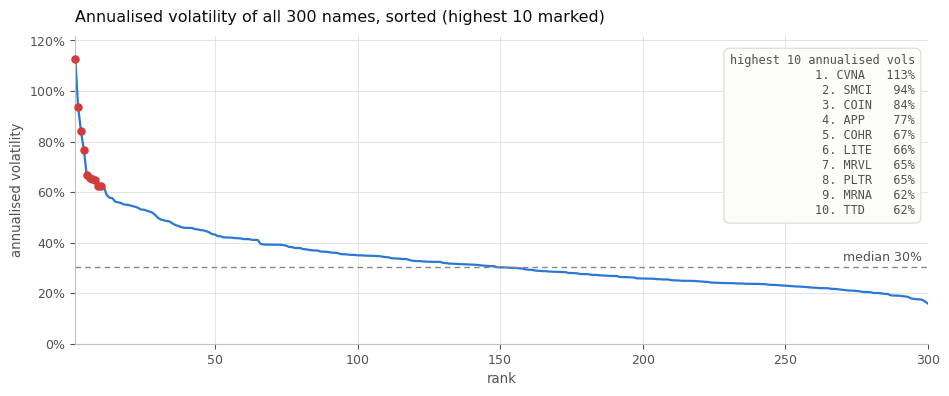

Highest 10 annualised volatilities:
CVNA   112.8%
SMCI    93.8%
COIN    84.0%
APP     76.8%
COHR    66.9%
LITE    65.8%
MRVL    65.0%
PLTR    64.7%
MRNA    62.4%
TTD     62.4%

Lowest 5 (the names a GMV portfolio will want to own):
RSG     17.6%
JNJ     17.6%
MCD     17.4%
BRK-B   16.7%
KO      15.9%

Cross-sectional vol: median 30.2%, range 15.9% to 112.8% (ratio 7.1x)


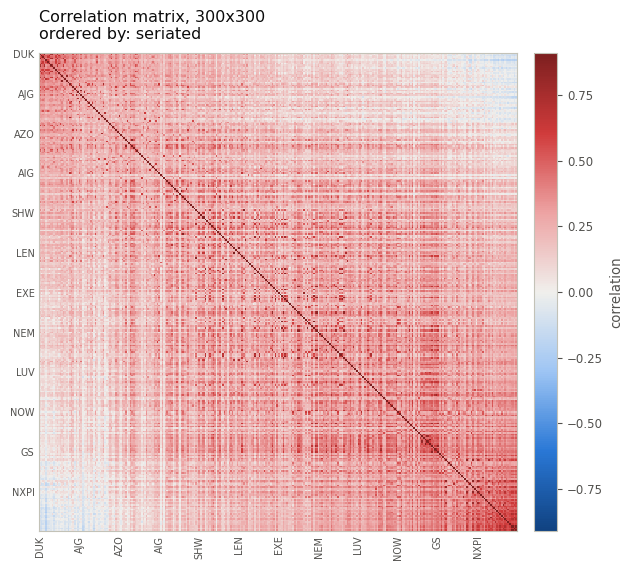

Off-diagonal correlations: mean +0.232, median +0.225, range -0.230 to +0.910
   fraction negative: 3.5%
   one-factor prediction for lambda_1 = 1 + rho_bar*(N-1) = 70.2   (actual 75.6)


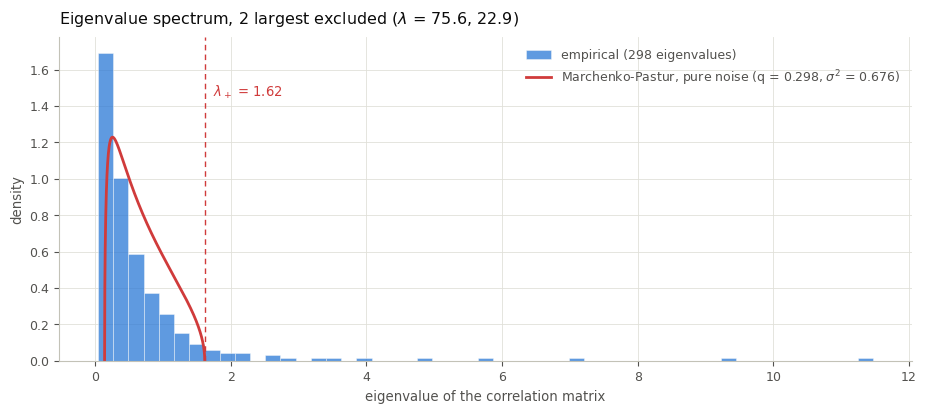


Spectrum (all 300 eigenvalues, T_eff = 1000, q = N/T_eff = 0.3000):
   sum = 300.00  (must equal N = 300, since Tr(C) = N)
   largest 5: 75.57, 22.91, 11.47, 9.33, 6.99
   smallest 5: 0.0554, 0.0516, 0.0497, 0.0472, 0.0427
   lambda_1 = 75.57 = 25.2% of total variance
   condition number lambda_1/lambda_N = 1768

   MP noise band for the plotted spectrum: [0.1395, 1.6161]
   eigenvalues above lambda_+ : 21  <- candidate real structure
   eigenvalues below lambda_- : 55  <- these should not exist under pure noise; they are the ones the RIE has to lift, and the ones that wreck Sigma^-1
   fraction of the spectrum inside the noise band: 74.5%


Market mode (lambda_1 = 75.6):
   share of stocks loading with the same sign: 100.0%
   loadings: min +0.0131, median +0.0555, max +0.0895   (uniform would be 0.0577)
   effective number of names carrying it: 235 of 300


In [10]:
# =============================================================================
# RAW COVARIANCE PIPELINE -- Cell 9 : the raw estimate on the full window
# =============================================================================
# Baseline case: equal weights (lam = 1), the entire 1000-day sample, N = 300.
# This is the "raw empirical covariance matrix" that Ledoit-Wolf and the RIE
# will be compared against, so it is worth looking at carefully once.

LAMBDA_EWMA = 1.0        # 1.0 = equal weights = plain sample covariance

Sigma_raw = ewma_covariance(returns, end_date=ANALYSIS_END,
                            T=len(returns), lam=LAMBDA_EWMA)
_, T_eff = ewma_weights(len(returns), LAMBDA_EWMA)

print(f"Sigma_raw: {Sigma_raw.shape[0]}x{Sigma_raw.shape[1]}, "
      f"T = {len(returns)}, T_eff = {T_eff:.1f}, "
      f"q = N/T_eff = {Sigma_raw.shape[0]/T_eff:.4f}")

# --- check that lam = 1 really is the plain sample covariance ------------------
# np.cov with ddof=0 is the 1/T-normalised estimator; rowvar=False because our
# rows are observations, not variables. If this passes, the EWMA generalisation
# has not quietly changed the baseline.
Sigma_check = np.cov(returns.to_numpy(), rowvar=False, ddof=0)
max_dev = np.abs(Sigma_raw.to_numpy() - Sigma_check).max()
print(f"max |Sigma_raw - np.cov(..., ddof=0)| = {max_dev:.3e}  "
      f"(should be ~1e-20, i.e. floating-point noise)")
assert np.allclose(Sigma_raw.to_numpy(), Sigma_check, atol=1e-16), \
    "lam = 1 does not reproduce the equal-weight sample covariance"

# Positive semi-definiteness is not an assumption here, it is guaranteed:
# Sigma = X_w^T X_w is a Gram matrix, so v^T Sigma v = |X_w v|^2 >= 0 for any v.
# With T > N it is strictly positive definite (generically). Confirm anyway,
# because everything downstream inverts this matrix.
eig_min = np.linalg.eigvalsh(Sigma_raw.to_numpy()).min()
print(f"smallest eigenvalue of Sigma_raw: {eig_min:.3e}  (> 0 required)")
assert eig_min > 0, "Sigma_raw is singular -- cannot be inverted"

# --- factor into vols and correlations ----------------------------------------
corr_raw, vol_raw = cov_to_corr(Sigma_raw)

assert np.allclose(np.diag(corr_raw.to_numpy()), 1.0), "diagonal must be exactly 1"
# Cross-check against pandas' own correlation, which computes it a completely
# different way (pairwise, ddof=1). Agreement to ~1e-12 means neither the
# weighting nor the normalisation has introduced an error.
print(f"max |corr_raw - returns.corr()| = "
      f"{np.abs(corr_raw.to_numpy() - returns.corr().to_numpy()).max():.3e}  "
      f"(scale-free, so the 1/T vs 1/(T-1) choice cancels)")

# --- diagnostics: full spectrum, then with the market mode removed -------------
print("\n" + "=" * 78)
print(" RAW CORRELATION MATRIX -- full spectrum")
print("=" * 78)
diag_raw = covariance_diagnostics(corr_raw, vol_raw, T_eff,
                                  n_mark=10, n_drop_largest=2)

print("\n" + "=" * 78)
# print(" SAME MATRIX -- market mode removed, so the bulk is visible")
# print("=" * 78)
# diag_bulk = covariance_diagnostics(corr_raw, vol_raw, T_eff,
#                                    n_mark=10, n_drop_largest=1)

# --- what the market mode actually is -----------------------------------------
# If lambda_1 is "the market", its eigenvector should load with the same sign on
# essentially every stock. Checking that is the difference between asserting the
# interpretation and verifying it.
u1 = diag_raw["eigvecs"][:, 0]
u1 = u1 * np.sign(u1.sum())          # fix the arbitrary global sign
print(f"\nMarket mode (lambda_1 = {diag_raw['eigvals'][0]:.1f}):")
print(f"   share of stocks loading with the same sign: {(u1 > 0).mean():.1%}")
print(f"   loadings: min {u1.min():+.4f}, median {np.median(u1):+.4f}, "
      f"max {u1.max():+.4f}   (uniform would be {1/np.sqrt(len(u1)):.4f})")
# Effective number of names carrying the mode: 1/sum(u^4) is the participation
# ratio again. Close to N means "everything", small means "a handful of stocks",
# which would mean lambda_1 is not really a market mode at all.
print(f"   effective number of names carrying it: {1/np.sum(u1**4):.0f} of {len(u1)}")

__Ledoit-Wolf linear shrinkage to identity__


using their estimate for the shrinkage intensity (based on minimizing Frobenius measure)

In [11]:
# =============================================================================
# LEDOIT-WOLF LINEAR SHRINKAGE -- Cell 10 : the estimator
# =============================================================================
# The estimator:
#
#       Xi_lin = alpha_s * E  +  (1 - alpha_s) * I_N,        alpha_s in [0, 1]
#
# where E is the sample correlation matrix. In the eigenbasis of E the
# eigenvectors are left completely untouched and only the eigenvalues move:
#
#       xi_i = 1 + alpha_s * (lambda_i - 1)
#
# i.e. a uniform contraction of the whole spectrum towards 1. Large eigenvalues
# come down, small ones go up, and because sum_i lambda_i = Tr(E) = N for any
# correlation matrix, sum_i xi_i = N too: the total variance is preserved for
# every alpha_s. The smallest eigenvalue is bounded below by 1 - alpha_s > 0, so
# the result is positive definite and safe to invert -- which is the entire
# point ("well-conditioned estimator").
#
# WHY THE IDENTITY TARGET AND NOT THE CONSTANT-CORRELATION ONE from "Honey, I
# Shrunk the Sample Covariance Matrix": because xi_i = f(lambda_i) with the
# eigenvectors preserved makes this a genuine Rotationally Invariant Estimator,
# the same family as the RIE in step 6. The three methods being compared then
# differ ONLY in their eigenvalue-shrinkage function f, which is exactly the
# comparison we want to isolate. The constant-correlation target rotates the
# eigenvectors and would confound it.
#
# WHY THIS FUNCTION NEEDS THE RETURNS, NOT JUST THE CORRELATION MATRIX. This is
# the structural difference from the RIE, and it is worth being clear about.
# The map lambda -> xi is a function of the eigenvalues alone, but the intensity
# alpha_s is not: it is estimated by minimising the expected squared Frobenius
# distance E||Xi - C||^2 to the unknown true C, and that expectation involves
# the *fourth* moments of the data -- how much the individual daily outer
# products y_t y_t^T scatter about their average E. Two datasets can share the
# same E (hence the same eigenvalues) and still deserve very different alpha_s,
# because one has its correlation carried steadily by every day and the other by
# a handful of violent days. So alpha_s cannot be read off the spectrum; the
# function takes R.
#
# WHY sklearn. `sklearn.covariance.LedoitWolf` implements Ledoit & Wolf (2004)
# directly, including the pi/gamma/kappa estimators behind alpha_s. A hand-coded
# transcription of the review's beta/gamma formula collapsed to alpha_s == 0 in
# every regime tested (a scaling inconsistency in how the y_k = z_k/sqrt(T)
# rescaling interacts with the fluctuation term), so sklearn is the reference
# implementation here, not a shortcut.
#
# THE ONE TRICK. sklearn shrinks towards mu * I_N with mu = Tr(S)/N, the average
# sample variance -- NOT towards I_N. Fed raw daily returns, mu would be the
# average daily return variance (~4e-4) and the target would be a nearly-zero
# matrix, which is not what we want. Feeding it the *z-scored* returns Z fixes
# this exactly: the sample covariance of Z IS the correlation matrix E, so
# mu = Tr(E)/N = 1 identically, sklearn's mu*I_N becomes exactly I_N, and its
# output is precisely Xi_lin above. Then alpha_s = 1 - lw.shrinkage_.


def lw_shrink_correlation(R, end_date=None, T=None):
    """
    Ledoit-Wolf linear shrinkage of the sample correlation matrix towards I_N.

    Parameters
    ----------
    R : pandas.DataFrame, shape (T_total, N)
        Returns, rows = dates (ascending), columns = tickers. Raw returns --
        this function does the standardisation internally.
    end_date, T :
        Same meaning as in `ewma_covariance` (cell 6): last day included, and
        how many observations to count back from it. Kept identical on purpose,
        so the walk-forward harness in step 4 can call every estimator through
        the same interface.

    Returns
    -------
    Xi_lin : pandas.DataFrame, shape (N, N)
        The shrunk correlation matrix. Diagonal exactly 1, trace exactly N.
    alpha_s : float in [0, 1]
        Weight kept on the sample correlation matrix E.
          alpha_s -> 1 : trust the data (T >> N, or strong real structure).
          alpha_s -> 0 : the sample matrix is mostly noise (q = N/T near 1, or
                         little genuine correlation), so shrink hard to I.
        Note sklearn reports the complement, `shrinkage_` = 1 - alpha_s, i.e.
        the weight on the target. Easy to mix up; hence the explicit name here.
    """
    # --- carve out the window (mirrors cell 6 deliberately) --------------------
    window = R if end_date is None else R.loc[:end_date]
    if T is not None:
        if len(window) < T:
            raise ValueError(f"asked for T = {T} ending {end_date}, "
                             f"only {len(window)} available")
        window = window.iloc[-T:]
    if window.isna().any().any():
        raise ValueError("NaNs in the estimation window")

    X = window.to_numpy(dtype=float)
    T_used, N = X.shape

    # --- standardise to unit variance so the target collapses to exactly I ----
    # ddof=0 to match the 1/T normalisation used everywhere in this project
    # (and everywhere in the Marchenko-Pastur literature).
    sd_R = X.std(axis=0, ddof=0)
    Z = (X - X.mean(axis=0)) / sd_R

    # Guard the standardisation. A column with zero variance inside some window
    # would divide by zero here and put inf/NaN into Z; LAPACK does not report
    # that as a NaN error, it reports it as a mysterious non-convergence
    # hundreds of rebalances later. Fail here instead, where the message is
    # useful. (Checked on this universe: the smallest per-window std over all
    # 500 windows is 8.1e-3, so this never fires -- it is a tripwire.)
    if not np.all(sd_R > 1e-12):
        dead = window.columns[sd_R <= 1e-12].tolist()
        raise ValueError(f"zero variance in the estimation window for {dead}")
    if not np.all(np.isfinite(Z)):
        raise ValueError("non-finite values after standardising the window")

    # store_precision=False is NOT an optimisation detail -- it matters.
    # LedoitWolf.fit() otherwise also computes precision_ = pinvh(covariance_),
    # and scipy's pinvh calls eigh with the LAPACK 'evr' driver, which on some
    # MKL/OpenBLAS builds intermittently fails with
    #     LinAlgError: The algorithm failed to converge; 298 off-diagonal
    #     elements of an intermediate tridiagonal form did not converge to zero
    # even on a perfectly well-conditioned 300x300 matrix. We never use
    # precision_ (GMV solves Sigma x = 1 by Cholesky in cell 16), so computing it
    # is pure risk. Switching it off also makes this call ~4.5x faster
    # (0.050s -> 0.011s per window), which over 500 rebalances is most of the
    # walk-forward runtime. covariance_ and shrinkage_ are bit-identical either
    # way -- verified.
    # assume_centered=False lets sklearn re-centre Z; Z is already centred to
    # machine precision, so that is a harmless no-op on its default code path.
    lw = LedoitWolf(assume_centered=False, store_precision=False).fit(Z)

    Xi = lw.covariance_                  # = alpha_s * E + (1 - alpha_s) * I_N
    alpha_s = float(1.0 - lw.shrinkage_)

    # Pin the diagonal. Analytically it is alpha_s*1 + (1-alpha_s)*1 = 1, but
    # sklearn re-centres internally so it lands at 1 +- 1e-16. Every downstream
    # step (the Sigma_ij = sigma_i sigma_j Xi_ij recombination below, the GMV
    # weights, the RIE comparison) assumes an exactly unit diagonal.
    Xi = 0.5 * (Xi + Xi.T)
    np.fill_diagonal(Xi, 1.0)

    return pd.DataFrame(Xi, index=window.columns, columns=window.columns), alpha_s


def corr_to_cov(corr, vol):
    """
    Inverse of `cov_to_corr`: Sigma_ij = sigma_i * sigma_j * Xi_ij.

    Two lines, but it earns a name because it is the seam where a *cleaned
    correlation matrix* becomes a *covariance matrix* usable for portfolio
    construction, and it silently assumes Xi_ii = 1. If a cleaning scheme
    returns a matrix whose diagonal has drifted (which the RIE does -- see
    `09_rie_iws.py`), this function will quietly distort every asset's variance
    instead of failing, so it checks.
    """
    C = np.asarray(corr, dtype=float)
    s = np.asarray(vol, dtype=float)
    if not np.allclose(np.diag(C), 1.0, atol=1e-10):
        raise ValueError("corr does not have a unit diagonal -- renormalise "
                         "before recombining, or the variances will be wrong")
    Sigma = C * np.outer(s, s)
    if isinstance(corr, pd.DataFrame):
        return pd.DataFrame(Sigma, index=corr.index, columns=corr.columns)
    return Sigma

In [12]:
# =============================================================================
# LEDOIT-WOLF LINEAR SHRINKAGE -- Cell 11 : diagnostics
# =============================================================================
# Two views, and between them they show the one thing worth understanding about
# linear shrinkage: it changes the AMPLITUDE of the correlation structure and
# nothing else.
#
#   (1) HEATMAPS, raw next to shrunk, on a SHARED colour scale. Off the diagonal
#       Xi_ij = alpha_s * E_ij exactly -- every entry multiplied by the same
#       number. So the second panel is the first one uniformly faded towards
#       grey: same blocks, same signs, same relative pattern, weaker. Plotting
#       them on separate autoscaled colour bars would hide precisely this (each
#       would fill its own range and the two would look identical), which is why
#       the scale is shared and taken from the raw matrix.
#
#       This is also the honest limitation of the method: it cannot tell a
#       genuine sector block from a noise fluctuation, because it applies the
#       same factor to both. That is exactly the gap the RIE tries to close, by
#       letting the shrinkage depend on where in the spectrum an eigenvalue sits.
#
#   (2) EIGENVALUE HISTOGRAM, raw and cleaned overlaid. The cleaned spectrum is
#       the raw one contracted towards 1: xi_i = 1 + alpha_s(lambda_i - 1).
#       What to look at:
#         * the bulk, which under pure noise would fill the Marchenko-Pastur
#           band [(1-sqrt q)^2, (1+sqrt q)^2], gets squeezed towards 1 -- and
#           since the bulk is mostly noise, squeezing it is the right move;
#         * the small eigenvalues, the dangerous ones (they are the near-zero
#           directions that a GMV portfolio piles into and that make Sigma^-1
#           explode), get lifted to at least 1 - alpha_s;
#         * the market eigenvalue is pulled down by the same factor, which is
#           the price paid: alpha_s is a single number, so real structure is
#           damped along with the noise.
#
# `n_drop_largest` works as in cell 8: the market mode is so large it flattens
# everything else on a linear axis, so drop it to see the bulk. Both spectra are
# truncated by the same amount so the comparison stays paired.


def lw_diagnostics(corr_raw, Xi_lin, alpha_s, T_eff, n_drop_largest=0,
                   order="seriated", show_heatmaps=True, figsize_scale=1.0):
    """
    Compare a raw sample correlation matrix with its Ledoit-Wolf shrunk version.

    Parameters
    ----------
    corr_raw : pandas.DataFrame, shape (N, N)
        Sample correlation matrix E (from `cov_to_corr`).
    Xi_lin : pandas.DataFrame, shape (N, N)
        Shrunk correlation matrix (from `lw_shrink_correlation`).
    alpha_s : float
        The shrinkage intensity that produced Xi_lin, for annotation and for the
        consistency check printed at the end.
    T_eff : float
        Effective sample size behind the estimate (from `ewma_weights`), used
        for the Marchenko-Pastur band.
    n_drop_largest : int
        Exclude this many largest eigenvalues from the histogram (0 = show all,
        1 = drop the market mode).
    show_heatmaps : bool
        The heatmaps do not depend on `n_drop_largest`, so set this False when
        calling the function a second time just to re-plot the spectrum with the
        market mode removed -- otherwise you get the same two heatmaps twice.
    order : {"seriated", "given"}
        Heatmap ordering, as in cell 8. Seriation is computed once from the RAW
        matrix and reused for both panels -- reordering each panel by its own
        eigenvectors would make them incomparable. (Harmless in fact, since
        shrinkage leaves eigenvectors untouched and would give the same order,
        but relying on that silently is how a bug hides.)

    Returns
    -------
    diag : dict
        {"eigvals_raw", "eigvals_lw", "order", "mp_edges", "q_eff"}
    """
    INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
    GRID, AXIS = "#e1e0d9", "#c3c2b7"
    BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#d03b3b"

    E = corr_raw.to_numpy(dtype=float) if isinstance(corr_raw, pd.DataFrame) \
        else np.asarray(corr_raw, dtype=float)
    X = Xi_lin.to_numpy(dtype=float) if isinstance(Xi_lin, pd.DataFrame) \
        else np.asarray(Xi_lin, dtype=float)
    names = list(corr_raw.index) if isinstance(corr_raw, pd.DataFrame) \
        else [str(i) for i in range(E.shape[0])]
    N = E.shape[0]
    if X.shape != E.shape:
        raise ValueError(f"shape mismatch: raw {E.shape} vs shrunk {X.shape}")

    # Descending eigenvalues, both matrices.
    ev_raw = np.linalg.eigvalsh(E)[::-1]
    ev_lw = np.linalg.eigvalsh(X)[::-1]
    # Seriation order from the raw matrix's second eigenvector (see cell 8).
    _, vecs_raw = np.linalg.eigh(E)
    u2 = vecs_raw[:, ::-1][:, 1]

    # ------------------------------------------------------------- (1) heatmaps
    perm = np.argsort(u2) if order == "seriated" else np.arange(N)
    if order not in ("seriated", "given"):
        raise ValueError('order must be "seriated" or "given"')
    heat_names = [names[i] for i in perm]
    E_ord = E[np.ix_(perm, perm)]
    X_ord = X[np.ix_(perm, perm)]

    # Shared, symmetric colour limits taken from the RAW off-diagonals, so grey
    # sits exactly on zero and the two panels are directly comparable.
    off = E_ord[~np.eye(N, dtype=bool)]
    vmax = float(np.abs(off).max())
    diverging = mpl.colors.LinearSegmentedColormap.from_list(
        "blue_grey_red",
        ["#104281", "#2a78d6", "#9ec5f4", "#f0efec",
         "#eda3a3", "#d03b3b", "#7d1f1f"])

    if show_heatmaps:
        fig1, axes = plt.subplots(1, 2, figsize=(12.4 * figsize_scale,
                                                5.6 * figsize_scale))
        for ax, M, label in ((axes[0], E_ord, "raw sample correlation $E$"),
                             (axes[1], X_ord,
                              f"Ledoit-Wolf shrunk $\\Xi^{{lin}}$  "
                              f"($\\alpha_s$ = {alpha_s:.3f})")):
            im = ax.imshow(M, cmap=diverging, vmin=-vmax, vmax=vmax,
                           interpolation="nearest", aspect="equal")
            step = max(1, N // 10)
            ax.set_xticks(np.arange(0, N, step))
            ax.set_xticklabels([heat_names[i] for i in range(0, N, step)],
                               rotation=90, fontsize=6.5)
            ax.set_yticks(np.arange(0, N, step))
            ax.set_yticklabels([heat_names[i] for i in range(0, N, step)],
                               fontsize=6.5)
            ax.set_title(label, loc="left", fontsize=10.5, color=INK, pad=8)
            ax.tick_params(colors=INK2, length=0)
            for s in ax.spines.values():
                s.set_color(AXIS)
        cbar = fig1.colorbar(im, ax=axes, fraction=0.024, pad=0.02)
        cbar.set_label("correlation (shared scale)", fontsize=9.5, color=INK2)
        cbar.outline.set_edgecolor(AXIS)
        cbar.ax.tick_params(colors=INK2, labelsize=8.5)
        fig1.suptitle(f"Linear shrinkage rescales the structure, it does not "
                      f"reshape it  (ordered by: {order})",
                      x=0.125, ha="left", fontsize=11.5, color=INK)
        plt.show()

        off_lw = X_ord[~np.eye(N, dtype=bool)]
        print(f"Off-diagonal correlations")
        print(f"   raw   : mean {off.mean():+.4f}, max {off.max():+.4f}, "
              f"min {off.min():+.4f}")
        print(f"   shrunk: mean {off_lw.mean():+.4f}, max {off_lw.max():+.4f}, "
              f"min {off_lw.min():+.4f}")
        # The identity Xi_ij = alpha_s * E_ij must hold entry by entry off the
        # diagonal. If it does not, either alpha_s is not the number that produced
        # Xi_lin, or the target was not exactly I.
        ratio_dev = np.abs(off_lw - alpha_s * off).max()
        print(f"   max |Xi_ij - alpha_s * E_ij| off-diagonal: {ratio_dev:.3e}  "
              f"(should be ~1e-16: shrinkage is exactly a uniform rescaling)")

    # -------------------------------------------------- (2) eigenvalue spectrum
    kept_raw = ev_raw[n_drop_largest:]
    kept_lw = ev_lw[n_drop_largest:]
    N_eff = len(kept_raw)
    q_eff = N_eff / T_eff
    # Residual per-direction variance after removing the top modes (= 1 exactly
    # when nothing is dropped, since sum(eigvals) = Tr(E) = N).
    sigma2 = kept_raw.sum() / N_eff
    lam_minus = sigma2 * (1 - np.sqrt(q_eff)) ** 2
    lam_plus = sigma2 * (1 + np.sqrt(q_eff)) ** 2

    fig2, ax = plt.subplots(figsize=(11 * figsize_scale, 4.4 * figsize_scale))
    # Shared bin edges, otherwise the two histograms are not comparable.
    lo = min(kept_raw.min(), kept_lw.min())
    hi = max(kept_raw.max(), kept_lw.max())
    bins = np.linspace(lo, hi, max(40, int(np.sqrt(N_eff) * 3)))
    ax.hist(kept_raw, bins=bins, density=True, color=BLUE, alpha=0.55,
            edgecolor="#fcfcfb", linewidth=0.4, label="raw $\\lambda_i$")
    ax.hist(kept_lw, bins=bins, density=True, color=ORANGE, alpha=0.65,
            edgecolor="#fcfcfb", linewidth=0.4,
            label=f"shrunk $\\xi_i = 1 + \\alpha_s(\\lambda_i - 1)$, "
                  f"$\\alpha_s$ = {alpha_s:.3f}")

    grid = np.linspace(lam_minus, lam_plus, 800)
    mp = np.sqrt(np.maximum((lam_plus - grid) * (grid - lam_minus), 0.0)) \
        / (2 * np.pi * q_eff * sigma2 * grid)
    ax.plot(grid, mp, color=RED, linewidth=2.0,
            label=f"Marchenko-Pastur, pure noise (q = {q_eff:.3f})")
    ax.axvline(1.0, color=MUTED, linewidth=1.2, linestyle=(0, (4, 3)))
    ax.annotate("shrinkage target: all $\\xi_i \\to 1$",
                xy=(1.0, ax.get_ylim()[1] * 0.9), xytext=(6, 0),
                textcoords="offset points", color=INK2, fontsize=9)

    ax.set_xlabel("eigenvalue", fontsize=9.5, color=INK2)
    ax.set_ylabel("density", fontsize=9.5, color=INK2)
    title = "Eigenvalue spectrum before and after linear shrinkage"
    if n_drop_largest:
        title += (f"  ({n_drop_largest} largest excluded: raw "
                  f"{', '.join(f'{v:.1f}' for v in ev_raw[:n_drop_largest])} "
                  f"-> shrunk "
                  f"{', '.join(f'{v:.1f}' for v in ev_lw[:n_drop_largest])})")
    ax.set_title(title, loc="left", fontsize=11.5, color=INK, pad=10)
    leg = ax.legend(frameon=False, fontsize=9, loc="upper right")
    for t in leg.get_texts():
        t.set_color(INK2)
    ax.grid(color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    plt.show()

    print(f"\nSpectrum, N = {N}, T_eff = {T_eff:.0f}, q = {N/T_eff:.4f}, "
          f"alpha_s = {alpha_s:.4f}")
    print(f"   {'':14s}{'raw':>12s}{'shrunk':>12s}")
    print(f"   {'trace':14s}{ev_raw.sum():>12.2f}{ev_lw.sum():>12.2f}"
          f"   <- both must equal N = {N}")
    print(f"   {'lambda_1':14s}{ev_raw[0]:>12.3f}{ev_lw[0]:>12.3f}")
    print(f"   {'lambda_min':14s}{ev_raw[-1]:>12.5f}{ev_lw[-1]:>12.5f}"
          f"   <- shrunk value is floored at 1 - alpha_s = {1-alpha_s:.5f}")
    print(f"   {'condition no.':14s}{ev_raw[0]/ev_raw[-1]:>12.4g}"
          f"{ev_lw[0]/ev_lw[-1]:>12.4g}"
          f"   <- improvement factor "
          f"{(ev_raw[0]/ev_raw[-1])/(ev_lw[0]/ev_lw[-1]):.4g}")
    print(f"\n   MP noise band for the plotted spectrum: "
          f"[{lam_minus:.4f}, {lam_plus:.4f}]")
    print(f"   raw eigenvalues inside it   : "
          f"{int(((kept_raw >= lam_minus) & (kept_raw <= lam_plus)).sum())}"
          f" / {N_eff}")
    print(f"   raw eigenvalues below lambda_-: {int((kept_raw < lam_minus).sum())}"
          f"   (these are what blow up Sigma^-1)")

    return {"eigvals_raw": ev_raw, "eigvals_lw": ev_lw, "order": heat_names,
            "mp_edges": (lam_minus, lam_plus), "q_eff": q_eff}

Ledoit-Wolf linear shrinkage, N = 300, T = 1000, q = 0.3000
   alpha_s (weight kept on the sample matrix E) = 0.9716
   1 - alpha_s (weight on the identity target)  = 0.0284

   max |Xi_lw - (alpha_s*E + (1-alpha_s)*I)| = 2.998e-15
   trace = 300.0000 (= N), lambda_min = 0.06990 >= 1 - alpha_s = 0.02838  OK

 LEDOIT-WOLF vs RAW


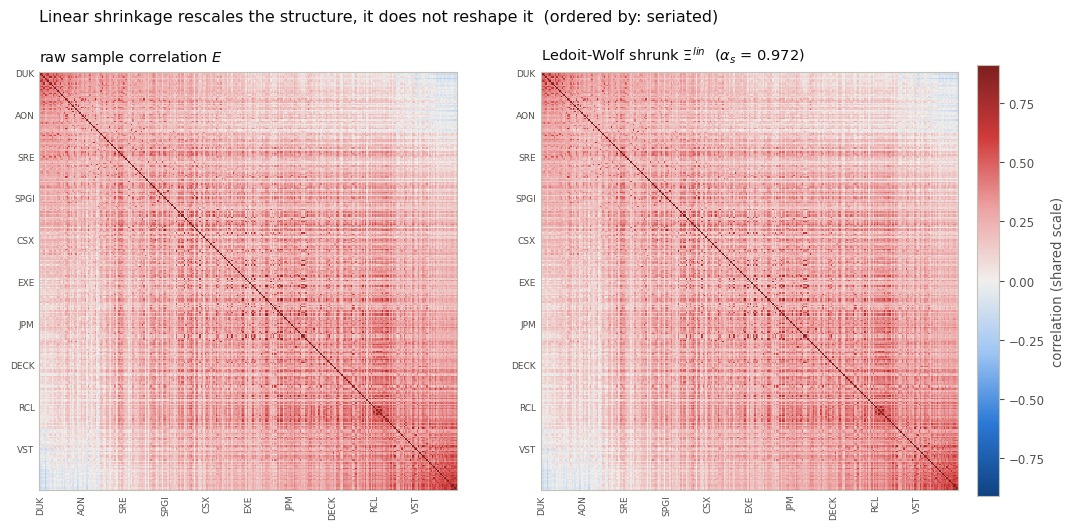

Off-diagonal correlations
   raw   : mean +0.2316, max +0.9102, min -0.2304
   shrunk: mean +0.2250, max +0.8844, min -0.2239
   max |Xi_ij - alpha_s * E_ij| off-diagonal: 2.998e-15  (should be ~1e-16: shrinkage is exactly a uniform rescaling)


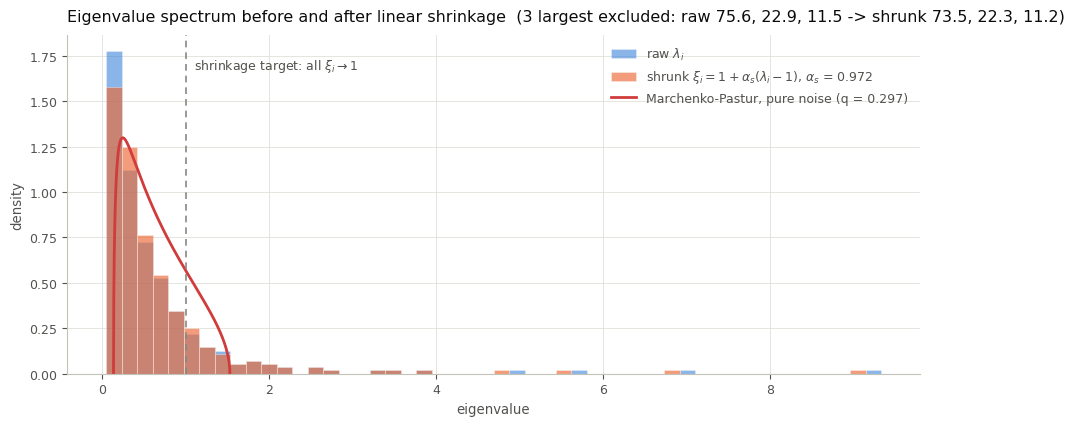


Spectrum, N = 300, T_eff = 1000, q = 0.3000, alpha_s = 0.9716
                          raw      shrunk
   trace               300.00      300.00   <- both must equal N = 300
   lambda_1            75.569      73.452
   lambda_min         0.04274     0.06990   <- shrunk value is floored at 1 - alpha_s = 0.02838
   condition no.         1768        1051   <- improvement factor 1.683

   MP noise band for the plotted spectrum: [0.1325, 1.5274]
   raw eigenvalues inside it   : 225 / 297
   raw eigenvalues below lambda_-: 50   (these are what blow up Sigma^-1)

Sigma_lw built from cleaned correlations x raw vols: (300, 300)
   max |diag(Sigma_lw) - diag(Sigma_raw)| = 2.168e-19   (must be 0: shrinking correlations must not touch variances)

Tr(E^-1)     =     1274.5
Tr(Xi_lw^-1) =     1066.2   (1.2x smaller)
Tr of the inverse is dominated by the smallest eigenvalues, so this ratio
is a direct measure of how much of the raw matrix's influence on a GMV
portfolio came from its noisiest, least

In [13]:
# =============================================================================
# LEDOIT-WOLF LINEAR SHRINKAGE -- Cell 12 : apply it to the full 1000-day window
# =============================================================================
# Same window as cell 9, so this is a like-for-like comparison against the raw
# matrix: N = 300, T = 1000, equal weights, ending ANALYSIS_END.

Xi_lw, alpha_s = lw_shrink_correlation(returns, end_date=ANALYSIS_END,
                                       T=len(returns))

print(f"Ledoit-Wolf linear shrinkage, N = {Xi_lw.shape[0]}, T = {len(returns)}, "
      f"q = {Xi_lw.shape[0]/len(returns):.4f}")
print(f"   alpha_s (weight kept on the sample matrix E) = {alpha_s:.4f}")
print(f"   1 - alpha_s (weight on the identity target)  = {1-alpha_s:.4f}")

# --- verify it really is alpha_s * E + (1 - alpha_s) * I ----------------------
# This is the check that the sklearn-plus-z-scoring trick did what the comment in
# cell 10 claims. If the target had come out as mu*I with mu != 1, this fails.
I_N = np.eye(Xi_lw.shape[0])
Xi_expected = alpha_s * corr_raw.to_numpy() + (1 - alpha_s) * I_N
max_dev = np.abs(Xi_lw.to_numpy() - Xi_expected).max()
print(f"\n   max |Xi_lw - (alpha_s*E + (1-alpha_s)*I)| = {max_dev:.3e}")
assert max_dev < 1e-12, \
    "sklearn's output is not alpha_s*E + (1-alpha_s)*I -- the identity target " \
    "collapsed incorrectly (check the z-scoring)"

# --- structural properties that must hold for any alpha_s ---------------------
ev_lw = np.linalg.eigvalsh(Xi_lw.to_numpy())
assert np.allclose(Xi_lw.to_numpy(), Xi_lw.to_numpy().T), "must be symmetric"
assert np.allclose(np.diag(Xi_lw.to_numpy()), 1.0), "diagonal must be exactly 1"
# Trace preservation: sum xi_i = sum [1 + alpha_s(lambda_i - 1)]
#                             = N + alpha_s(sum lambda_i - N) = N, since sum lambda_i = N.
assert np.isclose(ev_lw.sum(), Xi_lw.shape[0]), "trace must stay equal to N"
# Positive definiteness: xi_min = 1 + alpha_s(lambda_min - 1) >= 1 - alpha_s > 0.
assert ev_lw.min() > 0, "shrunk matrix should be positive definite"
assert ev_lw.min() >= (1 - alpha_s) - 1e-12, \
    "smallest eigenvalue below the 1 - alpha_s floor"
print(f"   trace = {ev_lw.sum():.4f} (= N), "
      f"lambda_min = {ev_lw.min():.5f} >= 1 - alpha_s = {1-alpha_s:.5f}  OK")

# --- diagnostics ---------------------------------------------------------------
print("\n" + "=" * 78)
print(" LEDOIT-WOLF vs RAW")
print("=" * 78)
diag_lw = lw_diagnostics(corr_raw, Xi_lw, alpha_s, T_eff, n_drop_largest=3)

# print("\n" + "=" * 78)
# print(" SAME -- market mode removed, so the bulk is visible")
# print("=" * 78)
# diag_lw_bulk = lw_diagnostics(corr_raw, Xi_lw, alpha_s, T_eff, n_drop_largest=1,
#                              show_heatmaps=False)

# --- the covariance matrix this implies ----------------------------------------
# Recombine with the raw volatilities (unchanged -- only the correlation matrix
# was cleaned). This is the Sigma that goes into the GMV portfolio in step 3.
Sigma_lw = corr_to_cov(Xi_lw, vol_raw)
print(f"\nSigma_lw built from cleaned correlations x raw vols: {Sigma_lw.shape}")
print(f"   max |diag(Sigma_lw) - diag(Sigma_raw)| = "
      f"{np.abs(np.diag(Sigma_lw.to_numpy()) - np.diag(Sigma_raw.to_numpy())).max():.3e}"
      f"   (must be 0: shrinking correlations must not touch variances)")

# --- how much does this matter for the object we actually care about? ----------
# The GMV portfolio needs Sigma^-1. A rough scalar proxy for "how much does
# cleaning change the answer" is how much the inverse changes, measured as the
# ratio of the sum of inverse eigenvalues (which is Tr(Sigma^-1), and is
# dominated by the smallest eigenvalues -- exactly the ones shrinkage repairs).
tr_inv_raw = float((1.0 / diag_lw["eigvals_raw"]).sum())
tr_inv_lw = float((1.0 / diag_lw["eigvals_lw"]).sum())
print(f"\nTr(E^-1)     = {tr_inv_raw:>10.1f}")
print(f"Tr(Xi_lw^-1) = {tr_inv_lw:>10.1f}   "
      f"({tr_inv_raw/tr_inv_lw:.1f}x smaller)")
print("Tr of the inverse is dominated by the smallest eigenvalues, so this ratio")
print("is a direct measure of how much of the raw matrix's influence on a GMV")
print("portfolio came from its noisiest, least trustworthy directions.")

RIE IWs (+15th percentile)

In [14]:
# =============================================================================
# RIE (IWs) -- Cell 13 : the estimator
# =============================================================================
# Same family as Ledoit-Wolf: eigenvectors untouched, eigenvalues remapped
# xi_i = f(lambda_i). The difference is the shape of f. LW is forced to be a
# straight line with a single global slope alpha_s, so a market eigenvalue of 75
# and a noise eigenvalue of 0.04 get the same treatment. The RIE lets f be
# nonlinear, estimating for EACH eigenvalue how much of it is signal, using the
# rest of the spectrum as the reference for what noise looks like.
#
# The machinery, in one paragraph. The optimal rotationally-invariant estimator
# is xi_i = <u_i, C u_i> -- the true variance along the i-th SAMPLE eigenvector.
# That is not computable (C is unknown), but RMT shows it has a large-N limit
# expressible through the Stieltjes transform g(z) = (1/N) sum_j 1/(z - lambda_j)
# of the empirical spectrum, evaluated just off the real axis at z = lambda_i - i*eta:
#
#       xi_i  =  Re(z) / |1 - q + q z g(z)|^2
#
# This is remarkable: an object that depends on the unknown C is recovered from
# the observed eigenvalues alone. It is also fragile at the bottom of the
# spectrum, where the density of eigenvalues is high and the finite-eta
# regularisation biases the answer -- hence the "IW" correction below.
#
# IW REGULARISATION. Near the left edge the estimate is repaired by comparing
# against a case where the exact answer IS known analytically: a true C drawn
# from an Inverse-Wishart distribution with shape kappa, for which g has a closed
# form (`_g_iw`). Running the same finite-eta formula on that reference and
# dividing the exact answer by it gives a correction factor Gamma ~ 1 that
# measures the bias, and it is applied where it matters (lambda_i < 1, Gamma > 1).
# The IW is a mathematical convenience, not a claim that stock correlations are
# IW-distributed.
#
# THE "s" IN IWs is a final sort: the theoretical map is monotonic in lambda, so
# any non-monotonicity at finite N is noise, and sorting the cleaned values back
# into descending order removes it. Cheap, and measurably helps.
#
# ---------------------------------------------------------------------------
# THE ONE DELIBERATE DEPARTURE FROM THE PUBLISHED ALGORITHM
# ---------------------------------------------------------------------------
# The paper calibrates kappa by matching the IW reference spectrum's lower edge
# to lambda_N, the single SMALLEST sample eigenvalue:
#
#       kappa = 2 lambda_N / [(1 - q - lambda_N)^2 - 4 q lambda_N]
#
# That is the most noise-sensitive number in the entire spectrum, and on real
# equity data it breaks the estimator. Genuine industry duopolies -- MA/V,
# HD/LOW, DAL/UAL, SO/DUK, correlated at 0.79-0.88 -- legitimately produce small
# eigenvalues that sit far below the bulk edge. lambda_N then drags kappa toward
# 0, the IW reference spectrum becomes absurdly wide, Gamma explodes and is
# applied across most of the spectrum, the bulk inflates, and because the trace
# is pinned at N the market mode gets squeezed out of the fixed budget (measured
# on this S&P universe: lambda_1 = 74.67 -> 55.87, a 25% haircut).
#
# Measured on synthetic data with KNOWN true C (N=300, T=1000, q=0.3), MSE
# against the oracle xi_i = <u_i, C u_i>:
#
#   scenario            kappa from lambda_N   kappa from p15    LW      raw
#   clean universe             0.0197             0.0199      0.157   0.164
#   25 industry pairs          1.9258             0.0120      0.127   0.128
#   40 industry pairs          1.8098             0.0148      0.116   0.117
#
# So the literal calibration is ~10-15x WORSE than no cleaning at all as soon as
# realistic structure is present, while calibrating on the 15th PERCENTILE of the
# spectrum costs essentially nothing on a clean universe and is 120-160x better
# on a realistic one. The percentile estimates where the bulk edge actually is
# while ignoring genuine low-end outliers -- the same logic the review applies at
# the TOP of the spectrum, where the machinery works on the "spikeless" matrix
# rather than the raw one.
#
# Note what this is NOT: it is not a data-quality problem, so the fix is not to
# delete stocks. An earlier attempt pruned 30 economically meaningful names and
# still failed to converge. The estimator needed fixing, not the universe.
# `kappa_pctile=None` recovers the paper's literal behaviour, kept so the failure
# is reproducible on demand.

KAPPA_CAP = 1e6      # numerical stand-in for kappa -> infinity (pure-noise limit)
GAMMA_CAP = 2.0      # safety net; theory says the correction is 1 + O(N^-1/4) ~ 1.3
KAPPA_PCTILE = 15.0  # percentile of the spectrum used to calibrate kappa
CAP_FRAC_WARN = 0.20 # warn if more than this fraction of Gamma values needed capping
MARKET_MODE_MIN_RATIO = 0.90   # cleaned lambda_1 / raw lambda_1 must exceed this


def _g_iw(z, q, kappa):
    """
    Stieltjes transform of the limiting sample-eigenvalue density when the TRUE
    correlation matrix is Inverse-Wishart with shape kappa. Closed form, so it
    serves as an exactly-known reference curve near the noisy left edge.

    kappa -> infinity recovers the null hypothesis C = I (pure Marchenko-Pastur);
    kappa -> 0 is an infinitely wide, uninformative prior.
    """
    root = np.sqrt((2 * kappa + 1) * (2 * q * kappa + 1))
    lam_plus = ((1 + q) * kappa + 1 + root) / kappa
    lam_minus = ((1 + q) * kappa + 1 - root) / kappa
    # The two sqrt factors are kept SEPARATE rather than combined into
    # sqrt((z-a)(z-b)): for complex z the principal branch of the product is not
    # the product of the principal branches, and combining them puts the result
    # on the wrong sheet for part of the spectrum.
    num = (z * (1 + kappa) - kappa * (1 - q)
           - np.sqrt(z - lam_plus) * np.sqrt(z - lam_minus))
    return num / (z * (z + 2 * q * kappa))


def _rie_shrinkage(z, q, g):
    """
    The core nonlinear map: a Stieltjes transform g evaluated just off the real
    axis -> a cleaned eigenvalue,  xi = Re(z) / |1 - q + q z g(z)|^2.
    Used twice, with two different g: once with the empirical resolvent (the
    actual estimate) and once with `_g_iw` (the reference for the bias
    correction). Only g differs, so it is worth having as one function.
    """
    return np.real(z) / np.abs(1 - q + q * z * g) ** 2


def rie_iws(eigvals, q, gamma_cap=GAMMA_CAP, kappa_pctile=KAPPA_PCTILE,
            verbose=True):
    """
    Clean sample-correlation eigenvalues with RIE (IWs).

    Parameters
    ----------
    eigvals : ndarray, shape (N,)
        Sample correlation eigenvalues, in any order.
    q : float
        N / T_eff.
    gamma_cap : float or None
        Cap on the small-eigenvalue correction factor (None = the literal
        published algorithm, uncapped).
    kappa_pctile : float or None
        Percentile of the spectrum used to calibrate kappa. None = lambda_N,
        i.e. the paper's version -- see the note above for why that fails.
    verbose : bool
        Print a warning when the calibration looks untrustworthy.

    Returns
    -------
    xi : ndarray, shape (N,)
        Cleaned eigenvalues, in the SAME order as the input.
    info : dict
        kappa, alpha_s, lam_N, lam_ref, max_gamma_raw, n_corrected, n_capped,
        cap_frac, trustworthy.
    """
    eigvals = np.asarray(eigvals, dtype=float)
    N = len(eigvals)

    # Descending, per the paper's convention; `order` restores the caller's.
    order = np.argsort(eigvals)[::-1]
    lam = eigvals[order]

    # --- Step 1: calibrate kappa ---------------------------------------------
    lam_N = float(lam[-1])
    lam_ref = lam_N if kappa_pctile is None else float(np.percentile(lam, kappa_pctile))
    denom = (1 - q - lam_ref) ** 2 - 4 * q * lam_ref
    if denom <= 0:
        # lam_ref sits at or beyond the null-hypothesis MP edge -- a common
        # finite-sample fluctuation. Stand in for kappa -> infinity (pure noise)
        # rather than let the formula return a negative, unphysical kappa.
        kappa = KAPPA_CAP
    else:
        kappa = min(2 * lam_ref / denom, KAPPA_CAP)

    # Same functional form as LW's shrinkage intensity, but DERIVED from kappa
    # rather than fitted to the data. Only used inside the Gamma correction.
    alpha_s = 1.0 / (1.0 + 2 * q * kappa)

    # --- Step 2: raw nonlinear RIE from the empirical resolvent ---------------
    # eta = N^(-1/2): far enough off the real axis for the sum to stay
    # well-conditioned, close enough to resolve individual eigenvalues.
    eta = N ** -0.5
    z = lam - 1j * eta

    # g(z_i) = (1/(N-1)) sum_{j != i} 1/(z_i - lambda_j).
    # Excluding j == i is essential: including it would add a 1/(-i*eta) term of
    # magnitude sqrt(N), swamping the sum. Vectorised as a full outer difference
    # with the diagonal subtracted off -- O(N^2) memory but N = 300 here.
    diff = z[:, None] - lam[None, :]
    inv = 1.0 / diff
    g_empirical = (inv.sum(axis=1) - np.diag(inv)) / (N - 1)

    xi_raw = _rie_shrinkage(z, q, g_empirical)

    # --- Step 3: IW bias correction at the bottom of the spectrum -------------
    # Gamma = (exact answer if C were IW) / (what the finite-eta formula returns
    # on that same reference). It measures the finite-eta bias, so it is ~1
    # except right at the hard left edge.
    xi_reference = _rie_shrinkage(z, q, _g_iw(z, q, kappa))
    Gamma = (1 + alpha_s * (lam - 1)) / xi_reference

    correct_mask = (Gamma > 1) & (lam < 1)
    max_gamma_raw = float(Gamma[correct_mask].max()) if correct_mask.any() else 1.0

    n_capped = 0
    if gamma_cap is not None:
        n_capped = int((Gamma[correct_mask] > gamma_cap).sum())
        Gamma = np.minimum(Gamma, gamma_cap)

    xi = xi_raw.copy()
    xi[correct_mask] = Gamma[correct_mask] * xi_raw[correct_mask]

    # --- Step 4: trace-preserving rescale ------------------------------------
    # Note this is made redundant by the unit-diagonal renormalisation in the
    # wrapper below (verified: scaling xi by any constant changes the final
    # matrix by 5e-16). Kept because it is step 7 of the published algorithm and
    # because it makes the intermediate `xi` directly comparable to `lam`.
    xi = xi * (lam.sum() / xi.sum())

    # --- Step 5: sort -- the "s" in IWs --------------------------------------
    xi_sorted = np.sort(xi)[::-1]
    xi_final = np.empty(N)
    xi_final[order] = xi_sorted

    cap_frac = n_capped / N
    # HEALTH METRIC: the FRACTION capped, not max(Gamma). Once kappa is
    # calibrated on a percentile, max(Gamma) is dominated by whatever single
    # near-degenerate direction exists and can read ~1e9 while the estimate as a
    # whole is fine. Cap fraction measured: healthy 0%, messy ~6%, broken 53-74%.
    trustworthy = cap_frac <= CAP_FRAC_WARN

    info = {"kappa": float(kappa), "alpha_s": float(alpha_s), "lam_N": lam_N,
            "lam_ref": lam_ref, "kappa_pctile": kappa_pctile,
            "max_gamma_raw": max_gamma_raw,
            "n_corrected": int(correct_mask.sum()), "n_capped": n_capped,
            "cap_frac": float(cap_frac), "trustworthy": bool(trustworthy)}

    if verbose and not trustworthy:
        print("*** WARNING: RIE calibration looks untrustworthy ***")
        print(f"    {n_capped} of {N} eigenvalues ({100*cap_frac:.0f}%) needed "
              f"capping at Gamma = {gamma_cap} -- healthy is 0%, >20% means the "
              f"calibration has gone bad.")
        print(f"    lambda_N = {lam_N:.4e}, lam_ref (p{kappa_pctile}) = "
              f"{lam_ref:.4f}, kappa = {kappa:.4g}")
        print("    Try raising kappa_pctile and inspect the low end of the spectrum.")

    return xi_final, info


def rie_shrink_correlation(R, end_date=None, T=None, gamma_cap=GAMMA_CAP,
                           kappa_pctile=KAPPA_PCTILE, verbose=True):
    """
    RIE (IWs) cleaning of the sample correlation matrix.

    Interface deliberately matches `lw_shrink_correlation` (cell 10) and
    `ewma_covariance` (cell 6): same end_date / T semantics, so the step-4
    backtest harness can call all three estimators identically.

    Returns
    -------
    Xi_rie : pandas.DataFrame, shape (N, N)
        Cleaned correlation matrix, unit diagonal.
    info : dict
        Diagnostics from `rie_iws`, plus q and the raw/cleaned eigenvalues.
    """
    window = R if end_date is None else R.loc[:end_date]
    if T is not None:
        if len(window) < T:
            raise ValueError(f"asked for T = {T} ending {end_date}, "
                             f"only {len(window)} available")
        window = window.iloc[-T:]
    if window.isna().any().any():
        raise ValueError("NaNs in the estimation window")

    A = window.to_numpy(dtype=float)
    T_used, N = A.shape
    q = N / T_used

    # Sample correlation matrix, 1/T convention (ddof=0) as everywhere else.
    Z = (A - A.mean(axis=0)) / A.std(axis=0, ddof=0)
    E = (Z.T @ Z) / T_used

    # eigh: symmetric solver, ascending eigenvalues, eigenvectors as columns.
    eigvals, eigvecs = np.linalg.eigh(E)

    xi, info = rie_iws(eigvals, q, gamma_cap=gamma_cap,
                       kappa_pctile=kappa_pctile, verbose=verbose)

    # Reconstruct Xi = V diag(xi) V^T with the ORIGINAL sample eigenvectors --
    # this is what makes the estimator rotationally invariant.
    Xi = eigvecs @ np.diag(xi) @ eigvecs.T
    Xi = 0.5 * (Xi + Xi.T)

    # NOT in the published algorithm, and it matters. The trace rescale only
    # pins the AVERAGE diagonal entry to 1; individual entries still drift
    # (0.73-1.15 observed here), because cleaning acts uniformly in the
    # eigenbasis, not asset by asset. Since the next step is
    # Sigma_ij = sigma_i sigma_j Xi_ij, that drift would silently distort each
    # asset's variance. Strictly this perturbs the eigenvectors, so the result
    # leaves the exactly-rotationally-invariant class -- but it enforces a
    # constraint the truth satisfies and measurably helps:
    # ||Xi - C||_F = 5.704 with, 6.085 without, 8.715 for the raw E.
    d = np.sqrt(np.diag(Xi))
    Xi = Xi / np.outer(d, d)
    np.fill_diagonal(Xi, 1.0)

    info["q"] = q
    info["T"] = T_used
    info["eigvals_raw"] = eigvals[::-1]          # descending
    info["xi_pre_renorm"] = np.sort(xi)[::-1]    # descending
    return pd.DataFrame(Xi, index=window.columns, columns=window.columns), info

In [15]:
# =============================================================================
# RIE (IWs) -- Cell 14 : diagnostics
# =============================================================================
# Same two views as the Ledoit-Wolf diagnostic in cell 11, so the two methods
# can be compared picture for picture:
#
#   (1) HEATMAPS, raw next to cleaned, shared colour scale. For LW this panel
#       showed a uniform fade: every off-diagonal entry multiplied by the same
#       alpha_s. Here it should NOT look like a uniform fade. The RIE damps the
#       noisy directions harder than the structured ones, so block structure
#       survives better relative to the background than it does under LW. That
#       difference is the whole point of the method, and the shared colour scale
#       is what makes it visible rather than normalised away.
#
#   (2) EIGENVALUE HISTOGRAM, raw and cleaned overlaid on shared bins, with the
#       Marchenko-Pastur noise band drawn for reference. Under LW the cleaned
#       spectrum was the raw one contracted towards 1 by a constant factor.
#       Here expect something qualitatively different: the bulk collapses
#       sharply towards 1 (it is noise, so it should), the small eigenvalues get
#       lifted, but the market mode is left almost where it was.
#
# Plus one panel the LW diagnostic did not need. There, the shrinkage function
# was a straight line and a single printed number (max |Xi_ij - alpha_s E_ij|)
# proved it. Here f is nonlinear and the only honest way to show it is to plot
# it: panel (3) is xi vs lambda on log-log axes, against the identity line
# (= no cleaning) and, if you pass alpha_s_lw, against the LW straight line. Set
# show_shrinkage_curve=False if you want strictly the two LW-style views.


def rie_diagnostics(corr_raw, Xi_rie, info, T_eff, n_drop_largest=0,
                    order="seriated", show_heatmaps=True,
                    show_shrinkage_curve=True, alpha_s_lw=None,
                    figsize_scale=1.0):
    """
    Compare a raw sample correlation matrix with its RIE (IWs) cleaned version.

    Parameters
    ----------
    corr_raw : pandas.DataFrame, shape (N, N)
        Sample correlation matrix E (from `cov_to_corr`).
    Xi_rie : pandas.DataFrame, shape (N, N)
        Cleaned correlation matrix (from `rie_shrink_correlation`).
    info : dict
        The info dict returned alongside Xi_rie -- used for kappa, the
        calibration reference eigenvalue, and the cap-fraction health check.
    T_eff : float
        Effective sample size (from `ewma_weights`), for the MP band.
    n_drop_largest : int
        Exclude this many largest eigenvalues from the histogram.
    show_heatmaps, show_shrinkage_curve : bool
        Neither depends on `n_drop_largest`, so switch them off when calling a
        second time just to re-plot the spectrum without the market mode.
    alpha_s_lw : float or None
        If given, overlay the Ledoit-Wolf line xi = 1 + alpha_s(lambda - 1) on
        the shrinkage-function panel. This is the most direct picture of what
        nonlinear cleaning buys over linear cleaning.

    Returns
    -------
    diag : dict
        {"eigvals_raw", "eigvals_rie", "order", "mp_edges", "q_eff"}
    """
    INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
    GRID, AXIS = "#e1e0d9", "#c3c2b7"
    BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#d03b3b"

    E = corr_raw.to_numpy(dtype=float) if isinstance(corr_raw, pd.DataFrame) \
        else np.asarray(corr_raw, dtype=float)
    X = Xi_rie.to_numpy(dtype=float) if isinstance(Xi_rie, pd.DataFrame) \
        else np.asarray(Xi_rie, dtype=float)
    names = list(corr_raw.index) if isinstance(corr_raw, pd.DataFrame) \
        else [str(i) for i in range(E.shape[0])]
    N = E.shape[0]
    if X.shape != E.shape:
        raise ValueError(f"shape mismatch: raw {E.shape} vs cleaned {X.shape}")

    ev_raw = np.linalg.eigvalsh(E)[::-1]
    ev_rie = np.linalg.eigvalsh(X)[::-1]
    _, vecs_raw = np.linalg.eigh(E)
    u2 = vecs_raw[:, ::-1][:, 1]

    # --- the calibration itself, before any picture ---------------------------
    print(f"RIE (IWs) calibration")
    print(f"   q = {info['q']:.4f},  T = {info.get('T', int(round(T_eff)))}, N = {N}")
    print(f"   lambda_N          = {info['lam_N']:.6f}   "
          f"(what the paper calibrates on)")
    print(f"   lam_ref (p{info['kappa_pctile']})  = {info['lam_ref']:.6f}   "
          f"(what we calibrate on)")
    print(f"   kappa             = {info['kappa']:.4g}")
    print(f"   alpha_s from kappa= {info['alpha_s']:.4f}   "
          f"(used inside the Gamma correction only)")
    print(f"   Gamma applied to  {info['n_corrected']} of {N} eigenvalues, "
          f"max raw Gamma {info['max_gamma_raw']:.3g}")
    print(f"   capped            {info['n_capped']} ({100*info['cap_frac']:.1f}%)"
          f"   -- healthy 0%, messy ~6%, broken >20%")
    print(f"   trustworthy       {info['trustworthy']}")

    # ------------------------------------------------------------- (1) heatmaps
    if order not in ("seriated", "given"):
        raise ValueError('order must be "seriated" or "given"')
    perm = np.argsort(u2) if order == "seriated" else np.arange(N)
    heat_names = [names[i] for i in perm]
    E_ord = E[np.ix_(perm, perm)]
    X_ord = X[np.ix_(perm, perm)]

    off = E_ord[~np.eye(N, dtype=bool)]
    off_rie = X_ord[~np.eye(N, dtype=bool)]
    vmax = float(np.abs(off).max())
    diverging = mpl.colors.LinearSegmentedColormap.from_list(
        "blue_grey_red",
        ["#104281", "#2a78d6", "#9ec5f4", "#f0efec",
         "#eda3a3", "#d03b3b", "#7d1f1f"])

    if show_heatmaps:
        fig1, axes = plt.subplots(1, 2, figsize=(12.4 * figsize_scale,
                                                5.6 * figsize_scale))
        for ax, M, label in ((axes[0], E_ord, "raw sample correlation $E$"),
                             (axes[1], X_ord,
                              f"RIE (IWs) cleaned $\\Xi^{{rie}}$  "
                              f"($\\kappa$ = {info['kappa']:.3g})")):
            im = ax.imshow(M, cmap=diverging, vmin=-vmax, vmax=vmax,
                           interpolation="nearest", aspect="equal")
            step = max(1, N // 10)
            ax.set_xticks(np.arange(0, N, step))
            ax.set_xticklabels([heat_names[i] for i in range(0, N, step)],
                               rotation=90, fontsize=6.5)
            ax.set_yticks(np.arange(0, N, step))
            ax.set_yticklabels([heat_names[i] for i in range(0, N, step)],
                               fontsize=6.5)
            ax.set_title(label, loc="left", fontsize=10.5, color=INK, pad=8)
            ax.tick_params(colors=INK2, length=0)
            for s in ax.spines.values():
                s.set_color(AXIS)
        cbar = fig1.colorbar(im, ax=axes, fraction=0.024, pad=0.02)
        cbar.set_label("correlation (shared scale)", fontsize=9.5, color=INK2)
        cbar.outline.set_edgecolor(AXIS)
        cbar.ax.tick_params(colors=INK2, labelsize=8.5)
        fig1.suptitle("Nonlinear cleaning: the fade is not uniform "
                      f"(ordered by: {order})",
                      x=0.125, ha="left", fontsize=11.5, color=INK)
        plt.show()

        print(f"\nOff-diagonal correlations")
        print(f"   raw    : mean {off.mean():+.4f}, max {off.max():+.4f}, "
              f"min {off.min():+.4f}")
        print(f"   cleaned: mean {off_rie.mean():+.4f}, max {off_rie.max():+.4f}, "
              f"min {off_rie.min():+.4f}")
        # For LW, Xi_ij / E_ij was the SAME constant alpha_s for every pair. Here
        # it is not, and the spread of that ratio is a one-number summary of how
        # far this estimator is from being linear. (Restricted to pairs with a
        # non-negligible raw correlation, since the ratio is meaningless where
        # E_ij ~ 0.)
        big = np.abs(off) > 0.1
        ratio = off_rie[big] / off[big]
        print(f"   Xi_ij / E_ij over the {big.sum():,} pairs with |E_ij| > 0.1: "
              f"mean {ratio.mean():.4f}, range {ratio.min():.4f} to {ratio.max():.4f}")
        print(f"   (a single constant here would mean the cleaning is linear; "
              f"the spread is the nonlinearity)")

    # -------------------------------------------------- (2) eigenvalue spectrum
    kept_raw = ev_raw[n_drop_largest:]
    kept_rie = ev_rie[n_drop_largest:]
    N_eff = len(kept_raw)
    q_eff = N_eff / T_eff
    sigma2 = kept_raw.sum() / N_eff
    lam_minus = sigma2 * (1 - np.sqrt(q_eff)) ** 2
    lam_plus = sigma2 * (1 + np.sqrt(q_eff)) ** 2

    fig2, ax = plt.subplots(figsize=(11 * figsize_scale, 4.4 * figsize_scale))
    lo = min(kept_raw.min(), kept_rie.min())
    hi = max(kept_raw.max(), kept_rie.max())
    bins = np.linspace(lo, hi, max(40, int(np.sqrt(N_eff) * 3)))
    ax.hist(kept_raw, bins=bins, density=True, color=BLUE, alpha=0.55,
            edgecolor="#fcfcfb", linewidth=0.4, label="raw $\\lambda_i$")
    ax.hist(kept_rie, bins=bins, density=True, color=AQUA, alpha=0.65,
            edgecolor="#fcfcfb", linewidth=0.4,
            label="RIE (IWs) cleaned $\\xi_i$")

    grid = np.linspace(lam_minus, lam_plus, 800)
    mp = np.sqrt(np.maximum((lam_plus - grid) * (grid - lam_minus), 0.0)) \
        / (2 * np.pi * q_eff * sigma2 * grid)
    ax.plot(grid, mp, color=RED, linewidth=2.0,
            label=f"Marchenko-Pastur, pure noise (q = {q_eff:.3f})")
    ax.axvline(1.0, color=MUTED, linewidth=1.2, linestyle=(0, (4, 3)))

    ax.set_xlabel("eigenvalue", fontsize=9.5, color=INK2)
    ax.set_ylabel("density", fontsize=9.5, color=INK2)
    title = "Eigenvalue spectrum before and after RIE (IWs) cleaning"
    if n_drop_largest:
        title += (f"  ({n_drop_largest} largest excluded: raw "
                  f"{', '.join(f'{v:.1f}' for v in ev_raw[:n_drop_largest])} "
                  f"-> cleaned "
                  f"{', '.join(f'{v:.1f}' for v in ev_rie[:n_drop_largest])})")
    ax.set_title(title, loc="left", fontsize=11.5, color=INK, pad=10)
    leg = ax.legend(frameon=False, fontsize=9, loc="upper right")
    for t in leg.get_texts():
        t.set_color(INK2)
    ax.grid(color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    plt.show()

    # -------------------------------------------- (3) the shrinkage function
    if show_shrinkage_curve:
        fig3, ax = plt.subplots(figsize=(7.6 * figsize_scale,
                                        6.0 * figsize_scale))
        # Log-log: lambda spans 0.04 to 75 here, and the interesting action is at
        # the small end, which a linear axis compresses into nothing.
        ax.plot(ev_raw, ev_raw, color=MUTED, linewidth=1.4,
                linestyle=(0, (4, 3)), label="no cleaning, $\\xi = \\lambda$")
        if alpha_s_lw is not None:
            lw_line = 1 + alpha_s_lw * (ev_raw - 1)
            ax.plot(ev_raw, lw_line, color=ORANGE, linewidth=2.0,
                    label=f"Ledoit-Wolf, $\\alpha_s$ = {alpha_s_lw:.3f}")
        ax.scatter(ev_raw, ev_rie, s=16, color=AQUA, zorder=3,
                   label="RIE (IWs)")
        ax.axhline(1.0, color=GRID, linewidth=1.0)
        ax.axvspan(lam_minus, lam_plus, color="#f0efec", zorder=0,
                   label=f"MP noise band [{lam_minus:.2f}, {lam_plus:.2f}]")

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("sample eigenvalue $\\lambda_i$", fontsize=9.5, color=INK2)
        ax.set_ylabel("cleaned eigenvalue $\\xi_i$", fontsize=9.5, color=INK2)
        ax.set_title("The shrinkage function: what each method does to each "
                     "eigenvalue", loc="left", fontsize=11.5, color=INK, pad=10)
        leg = ax.legend(frameon=False, fontsize=9, loc="lower right")
        for t in leg.get_texts():
            t.set_color(INK2)
        ax.grid(color=GRID, linewidth=0.6, which="both")
        ax.set_axisbelow(True)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
        for s in ("left", "bottom"):
            ax.spines[s].set_color(AXIS)
        ax.tick_params(colors=INK2, labelsize=9)
        plt.show()

    # --- numbers ---------------------------------------------------------------
    print(f"\nSpectrum, N = {N}, T_eff = {T_eff:.0f}, q = {N/T_eff:.4f}")
    print(f"   {'':16s}{'raw':>12s}{'RIE':>12s}")
    print(f"   {'trace':16s}{ev_raw.sum():>12.2f}{ev_rie.sum():>12.2f}"
          f"   <- both must equal N = {N}")
    print(f"   {'lambda_1':16s}{ev_raw[0]:>12.3f}{ev_rie[0]:>12.3f}"
          f"   <- ratio {ev_rie[0]/ev_raw[0]:.3f} (oracle 0.96-1.02 on healthy data)")
    print(f"   {'lambda_min':16s}{ev_raw[-1]:>12.5f}{ev_rie[-1]:>12.5f}")
    print(f"   {'condition no.':16s}{ev_raw[0]/ev_raw[-1]:>12.4g}"
          f"{ev_rie[0]/ev_rie[-1]:>12.4g}"
          f"   <- improvement factor "
          f"{(ev_raw[0]/ev_raw[-1])/(ev_rie[0]/ev_rie[-1]):.4g}")
    n_in = int(((kept_raw >= lam_minus) & (kept_raw <= lam_plus)).sum())
    print(f"\n   MP noise band for the plotted spectrum: "
          f"[{lam_minus:.4f}, {lam_plus:.4f}]")
    print(f"   raw eigenvalues inside it: {n_in} / {N_eff}   "
          f"-- these are the ones with no recoverable signal")
    # How far did the bulk actually get compressed? The interquartile range of
    # the eigenvalues inside the noise band is a compact measure.
    in_band = (kept_raw >= lam_minus) & (kept_raw <= lam_plus)
    if in_band.sum() > 4:
        iqr_raw = np.subtract(*np.percentile(kept_raw[in_band], [75, 25]))
        iqr_rie = np.subtract(*np.percentile(kept_rie[in_band], [75, 25]))
        print(f"   IQR of the in-band eigenvalues: raw {iqr_raw:.4f} -> "
              f"cleaned {iqr_rie:.4f}  ({iqr_raw/max(iqr_rie,1e-12):.1f}x "
              f"narrower -- the noise being squeezed out)")

    return {"eigvals_raw": ev_raw, "eigvals_rie": ev_rie, "order": heat_names,
            "mp_edges": (lam_minus, lam_plus), "q_eff": q_eff}

Xi_rie: symmetric, unit diagonal, positive definite (lambda_min = 0.16)
Market mode: raw 75.57 -> cleaned 71.96 (ratio 0.952)

 RIE (IWs) vs RAW -- full spectrum
RIE (IWs) calibration
   q = 0.3000,  T = 1000, N = 300
   lambda_N          = 0.042738   (what the paper calibrates on)
   lam_ref (p15.0)  = 0.121636   (what we calibrate on)
   kappa             = 1.29
   alpha_s from kappa= 0.5636   (used inside the Gamma correction only)
   Gamma applied to  108 of 300 eigenvalues, max raw Gamma 4.15
   capped            28 (9.3%)   -- healthy 0%, messy ~6%, broken >20%
   trustworthy       True


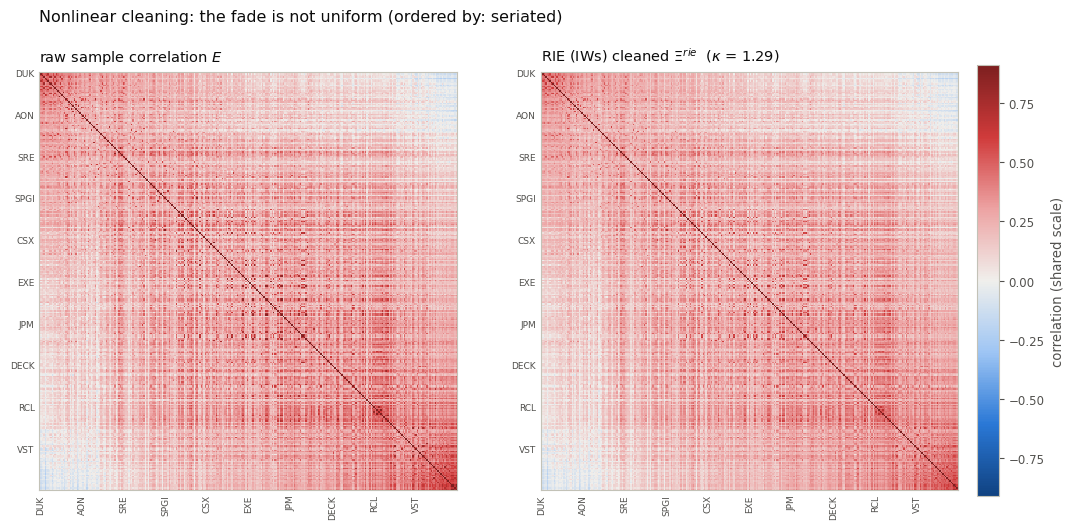


Off-diagonal correlations
   raw    : mean +0.2316, max +0.9102, min -0.2304
   cleaned: mean +0.2219, max +0.7850, min -0.2103
   Xi_ij / E_ij over the 75,964 pairs with |E_ij| > 0.1: mean 0.9661, range 0.7447 to 1.3425
   (a single constant here would mean the cleaning is linear; the spread is the nonlinearity)


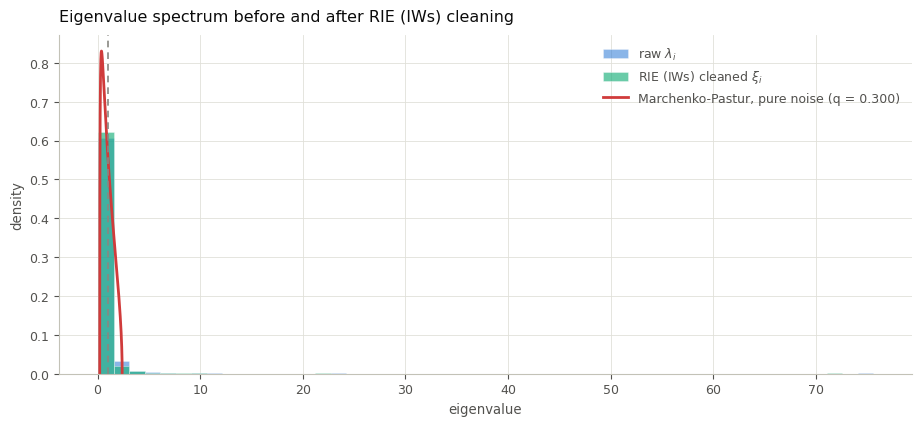

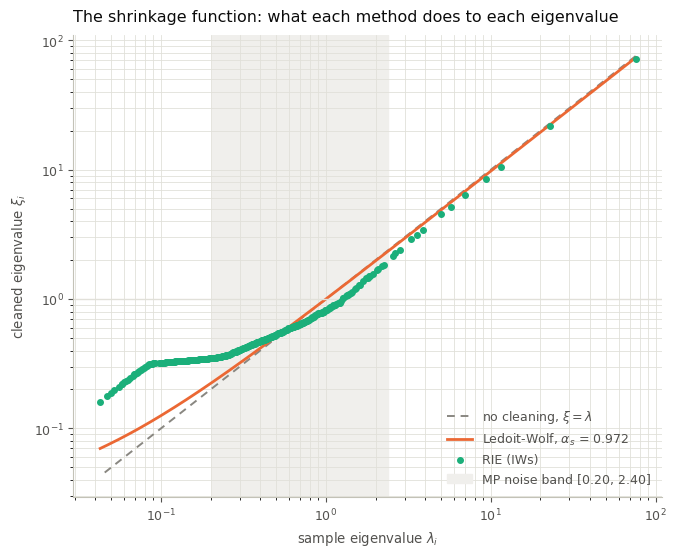


Spectrum, N = 300, T_eff = 1000, q = 0.3000
                            raw         RIE
   trace                 300.00      300.00   <- both must equal N = 300
   lambda_1              75.569      71.956   <- ratio 0.952 (oracle 0.96-1.02 on healthy data)
   lambda_min           0.04274     0.16003
   condition no.           1768       449.6   <- improvement factor 3.932

   MP noise band for the plotted spectrum: [0.2046, 2.3954]
   raw eigenvalues inside it: 200 / 300   -- these are the ones with no recoverable signal
   IQR of the in-band eigenvalues: raw 0.5284 -> cleaned 0.3180  (1.7x narrower -- the noise being squeezed out)

 SAME -- market mode removed, so the bulk is visible
RIE (IWs) calibration
   q = 0.3000,  T = 1000, N = 300
   lambda_N          = 0.042738   (what the paper calibrates on)
   lam_ref (p15.0)  = 0.121636   (what we calibrate on)
   kappa             = 1.29
   alpha_s from kappa= 0.5636   (used inside the Gamma correction only)
   Gamma applied to  108 of 

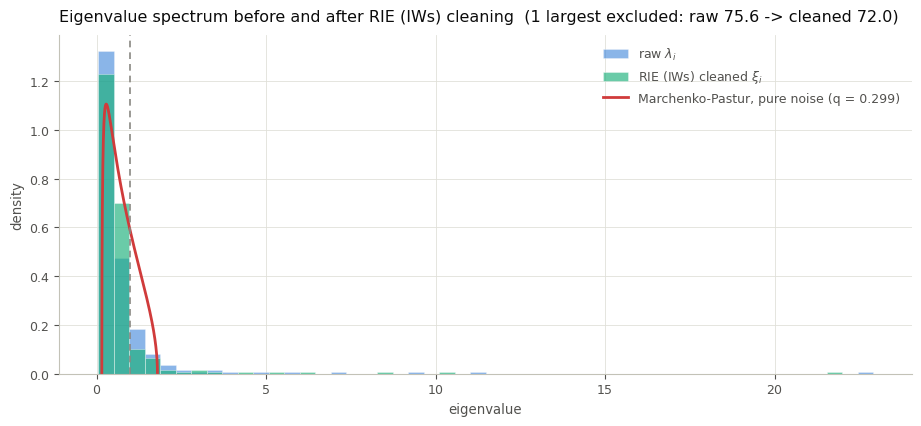


Spectrum, N = 300, T_eff = 1000, q = 0.3000
                            raw         RIE
   trace                 300.00      300.00   <- both must equal N = 300
   lambda_1              75.569      71.956   <- ratio 0.952 (oracle 0.96-1.02 on healthy data)
   lambda_min           0.04274     0.16003
   condition no.           1768       449.6   <- improvement factor 3.932

   MP noise band for the plotted spectrum: [0.1542, 1.7959]
   raw eigenvalues inside it: 217 / 299   -- these are the ones with no recoverable signal
   IQR of the in-band eigenvalues: raw 0.4819 -> cleaned 0.2854  (1.7x narrower -- the noise being squeezed out)

 THE PAPER'S LITERAL CALIBRATION (kappa from lambda_N) -- for contrast
*** WARNING: RIE calibration looks untrustworthy ***
    194 of 300 eigenvalues (65%) needed capping at Gamma = 2.0 -- healthy is 0%, >20% means the calibration has gone bad.
    lambda_N = 4.2738e-02, lam_ref (pNone) = 0.0427, kappa = 0.2245
    Try raising kappa_pctile and inspect the

In [16]:
# =============================================================================
# RIE (IWs) -- Cell 15 : apply it to the full 1000-day window
# =============================================================================
# Same window as cells 9 and 12: N = 300, T = 1000, q = 0.30, ending ANALYSIS_END.

Xi_rie, rie_info = rie_shrink_correlation(returns, end_date=ANALYSIS_END,
                                         T=len(returns),
                                         kappa_pctile=KAPPA_PCTILE)

# --- structural checks ---------------------------------------------------------
ev_rie = np.linalg.eigvalsh(Xi_rie.to_numpy())
assert np.allclose(Xi_rie.to_numpy(), Xi_rie.to_numpy().T), "must be symmetric"
assert np.allclose(np.diag(Xi_rie.to_numpy()), 1.0), "diagonal must be exactly 1"
assert ev_rie.min() > 0, "must be positive definite (it gets inverted later)"
print(f"Xi_rie: symmetric, unit diagonal, positive definite "
      f"(lambda_min = {ev_rie.min():.4g})")

# The check that catches the known failure mode. If the small eigenvalues get
# over-inflated, the fixed trace budget squeezes the market mode -- that is
# exactly what the paper's lambda_N calibration did here (74.67 -> 55.87, ratio
# 0.748). On healthy data the oracle ratio is 0.96-1.02.
ev_raw_desc = np.linalg.eigvalsh(corr_raw.to_numpy())[::-1]
market_ratio = ev_rie.max() / ev_raw_desc[0]
print(f"Market mode: raw {ev_raw_desc[0]:.2f} -> cleaned {ev_rie.max():.2f} "
      f"(ratio {market_ratio:.3f})")
assert market_ratio > MARKET_MODE_MIN_RATIO, (
    f"market mode shrunk to {market_ratio:.3f} of raw -- the small eigenvalues "
    f"were over-inflated and ate the trace budget. Raise kappa_pctile.")
assert rie_info["trustworthy"], "calibration flagged untrustworthy"

# --- diagnostics ---------------------------------------------------------------
print("\n" + "=" * 78)
print(" RIE (IWs) vs RAW -- full spectrum")
print("=" * 78)
diag_rie = rie_diagnostics(corr_raw, Xi_rie, rie_info, T_eff,
                           n_drop_largest=0, alpha_s_lw=alpha_s)

print("\n" + "=" * 78)
print(" SAME -- market mode removed, so the bulk is visible")
print("=" * 78)
diag_rie_bulk = rie_diagnostics(corr_raw, Xi_rie, rie_info, T_eff,
                                n_drop_largest=1, show_heatmaps=False,
                                show_shrinkage_curve=False)

# --- reproduce the published calibration, to see it fail -----------------------
# Worth running once: kappa_pctile=None is the literal algorithm from the paper.
# verbose=True will print the untrustworthy-calibration warning.
print("\n" + "=" * 78)
print(" THE PAPER'S LITERAL CALIBRATION (kappa from lambda_N) -- for contrast")
print("=" * 78)
Xi_paper, info_paper = rie_shrink_correlation(returns, end_date=ANALYSIS_END,
                                             T=len(returns), kappa_pctile=None)
ev_paper = np.linalg.eigvalsh(Xi_paper.to_numpy())
print(f"   kappa = {info_paper['kappa']:.4g}  (vs {rie_info['kappa']:.4g} with p15)")
print(f"   capped {info_paper['n_capped']} of {len(ev_paper)} "
      f"({100*info_paper['cap_frac']:.0f}%)")
print(f"   market mode ratio = {ev_paper.max()/ev_raw_desc[0]:.3f}  "
      f"(vs {market_ratio:.3f} with p15; healthy is 0.96-1.02)")
print(f"   ||Xi - E||_F = {np.linalg.norm(Xi_paper.to_numpy() - corr_raw.to_numpy()):.3f}"
      f"  (vs {np.linalg.norm(Xi_rie.to_numpy() - corr_raw.to_numpy()):.3f} with p15)")

# --- the covariance matrix this implies ----------------------------------------
Sigma_rie = corr_to_cov(Xi_rie, vol_raw)
print(f"\nSigma_rie built from cleaned correlations x raw vols: {Sigma_rie.shape}")

# --- three-way comparison ------------------------------------------------------
# All on the same window, so this is the like-for-like summary. Realised
# out-of-sample volatility (step 4) is the verdict; these are the properties
# that should predict it.
print("\n" + "=" * 78)
print(" RAW vs LEDOIT-WOLF vs RIE (IWs), same window")
print("=" * 78)
ev_lw_desc = np.linalg.eigvalsh(Xi_lw.to_numpy())[::-1]
ev_rie_desc = ev_rie[::-1]
rows = [("raw E", ev_raw_desc), ("Ledoit-Wolf", ev_lw_desc), ("RIE (IWs)", ev_rie_desc)]
print(f"{'':14s}{'lambda_1':>11s}{'lambda_min':>12s}{'cond. no.':>12s}"
      f"{'Tr(inv)':>11s}{'||Xi-E||_F':>12s}")
for label, ev in rows:
    M = {"raw E": corr_raw, "Ledoit-Wolf": Xi_lw, "RIE (IWs)": Xi_rie}[label]
    frob = np.linalg.norm(M.to_numpy() - corr_raw.to_numpy())
    print(f"{label:14s}{ev[0]:>11.3f}{ev[-1]:>12.5f}{ev[0]/ev[-1]:>12.4g}"
          f"{(1.0/ev).sum():>11.1f}{frob:>12.3f}")
print("\nTr(inv) is dominated by the smallest eigenvalues, i.e. by exactly the")
print("directions a GMV portfolio will lever up. ||Xi - E||_F says how far each")
print("method moved from the raw matrix -- note LW and RIE can move a similar")
print("distance while moving in very different directions.")

Global Minimum Variance portfolio

In [20]:
# =============================================================================
# GMV PORTFOLIO -- Cell 16 : weights from a covariance matrix
# =============================================================================
# The global minimum-variance portfolio: minimise w' Sigma w subject to
# sum_i w_i = 1, no expected-return input at all. The solution is
#
#       w = Sigma^-1 1 / (1' Sigma^-1 1)
#
# GMV is the right test vehicle for this project precisely BECAUSE it has no
# alpha model in it. Any difference in realised risk between the three
# portfolios is attributable to the covariance estimate and nothing else.
#
# It is also the harshest possible test of the estimate, for a reason worth
# understanding. Write Sigma = sum_k xi_k v_k v_k' and expand:
#
#       Sigma^-1 1 = sum_k (v_k' 1 / xi_k) v_k
#
# The weight on direction k is divided by xi_k. So the portfolio loads MOST
# heavily on the SMALLEST-eigenvalue directions -- exactly the directions where
# the sample matrix is least reliable, and exactly the ones cleaning repairs. An
# eigenvalue underestimated by a factor of 5 becomes a weight overestimated by a
# factor of 5, and the optimiser piles into a combination it wrongly believes is
# low risk. That mechanism is the whole reason this comparison has any teeth.
#
# NO SHORT-SALE CONSTRAINT. Imposing w >= 0 would act as a powerful implicit
# regulariser -- it bounds leverage, and it stops the optimiser from taking the
# huge offsetting long/short bets that noisy small eigenvalues invite. That would
# mask precisely the differences we are trying to measure. Unconstrained is the
# honest choice here, even though it produces weights no one would trade.
#
# SOLVE, DON'T INVERT. Sigma^-1 is never formed. `cho_factor` / `cho_solve`
# solves Sigma x = 1 via the Cholesky factorisation Sigma = L L', which is
# roughly twice as fast as a general LU solve, numerically better behaved for a
# symmetric positive-definite matrix, and -- usefully -- FAILS LOUDLY with
# LinAlgError if Sigma is not positive definite, instead of silently returning
# garbage the way an explicit inverse would.


def gmv_weights(Sigma, extreme_threshold=0.05):
    """
    Global minimum-variance weights and the diagnostics worth logging per rebalance.

    Parameters
    ----------
    Sigma : pandas.DataFrame or ndarray, shape (N, N)
        Covariance matrix (in daily return units, per this project).
    extreme_threshold : float
        A weight is flagged "extreme" if |w_i| exceeds this. 0.05 = 5% of the
        book in one name, against an equal-weight benchmark of 1/300 = 0.33%.

    Returns
    -------
    w : pandas.Series or ndarray, shape (N,)
        Weights, summing to exactly 1. Can be (and will be) negative.
    info : dict
        pred_var    : the portfolio variance Sigma PREDICTS for itself,
                      w' Sigma w = 1 / (1' Sigma^-1 1). Comparing this against
                      the realised out-of-sample variance is the calibration
                      test -- the raw sample matrix is known to understate its
                      own risk by roughly a factor (1 - q).
        pred_vol_ann: the same, annualised (sqrt(252 * pred_var)), for reading.
        leverage    : gross leverage sum_i |w_i|. Equals 1 for a long-only
                      book; uncleaned GMV routinely produces 5-15.
        eff_n       : effective number of positions, 1 / sum_i w_i^2. Equals N
                      for equal weight, and collapses when the optimiser chases
                      a handful of spurious low-risk combinations.
        n_extreme   : how many |w_i| > extreme_threshold.
        max_abs_w   : the single largest absolute weight.
        lam_min, cond : smallest eigenvalue and condition number of Sigma. These
                      explain *why* the weights look the way they do.
    """
    labels = Sigma.index if isinstance(Sigma, pd.DataFrame) else None
    S = np.asarray(Sigma, dtype=float)
    N = S.shape[0]
    ones = np.ones(N)

    # Cholesky factorisation; raises LinAlgError if Sigma is not PD.
    c, low = cho_factor(S, lower=True, check_finite=False)
    x = cho_solve((c, low), ones, check_finite=False)   # x = Sigma^-1 1

    denom = float(ones @ x)                             # 1' Sigma^-1 1
    if denom <= 0:
        raise np.linalg.LinAlgError(
            f"1' Sigma^-1 1 = {denom:.3e} <= 0; Sigma is not positive definite")
    w = x / denom

    # w' Sigma w collapses to 1/(1' Sigma^-1 1) for the GMV solution. Using the
    # closed form rather than recomputing the quadratic form avoids a second
    # matrix product and is exact.
    pred_var = 1.0 / denom

    eigs = np.linalg.eigvalsh(S)
    info = {
        "pred_var": pred_var,
        "pred_vol_ann": float(np.sqrt(252.0 * pred_var)),
        "leverage": float(np.abs(w).sum()),
        "eff_n": float((np.sum(np.abs(w)))**2 / np.sum(w ** 2)),
        "n_extreme": int((np.abs(w) > extreme_threshold).sum()),
        "max_abs_w": float(np.abs(w).max()),
        "lam_min": float(eigs.min()),
        "cond": float(eigs.max() / eigs.min()),
    }

    if labels is not None:
        return pd.Series(w, index=labels, name="w"), info
    return w, info

WALK FORWARD:

In [21]:
# =============================================================================
# WALK-FORWARD EVALUATION -- Cell 17 : the harness
# =============================================================================
# Strict out-of-sample protocol, no look-ahead anywhere:
#
#   at rebalance index t:
#     1. estimation window = R.iloc[t-T : t]        <- ends at t-1, EXCLUDES t
#     2. estimate Sigma_t on that window only
#     3. w_t = GMV(Sigma_t)
#     4. hold for T_out days and record w_t' r_{t+k}, k = 0 .. T_out-1
#     5. t += T_out, repeat
#
# ROLLING, FIXED-LENGTH WINDOW, not expanding. This keeps q = N/T constant
# across the whole backtest. An expanding window would let q drift from 0.6 down
# to 0.3 over the sample, and since q is the very parameter that governs how much
# cleaning helps, a drifting q would confound the result with the thing being
# measured.
#
# T_out = 1 (daily rebalancing). With 1000 total days and T = 500 this gives
# M = 500 out-of-sample observations; M = T_tot - T is the binding constraint on
# statistical power, so short holding periods buy resolution. Longer T_out is a
# turnover-realism check to run afterwards, not the primary comparison.
#
# WHAT GETS RECORDED. One row per out-of-sample DAY, so that all estimators share
# an identical index and the paired comparison in the summary is exact. Rebalance-
# level quantities (leverage, predicted risk, turnover) are constant within a
# holding block and simply repeat, which is the right thing for T_out = 1 and
# still correct for larger.
#
# RETURNS ARE NOT DEMEANED anywhere in the risk calculations. For a
# minimum-variance study the object of interest is second-moment risk, and
# subtracting a noisily estimated in-sample mean injects avoidable estimation
# error. This is standard in the literature and is why the volatility formula
# below is sqrt(252/M * sum r_p^2) rather than a sample standard deviation.


def walk_forward(R, estimator, T=500, T_out=1, name="", verbose=True,
                 extreme_threshold=0.05, keep_weights=False):
    """
    Roll an estimator forward through the sample and record realised performance.

    Parameters
    ----------
    R : pandas.DataFrame, shape (T_tot, N)
        Returns panel, dates ascending, no NaNs.
    estimator : callable
        `estimator(R_window) -> (Sigma, info)` where R_window is a (T, N)
        DataFrame and Sigma is an (N, N) covariance DataFrame. `info` is a dict
        of estimator-specific scalars to log (e.g. alpha_s, kappa); pass {} if
        there are none. Keeping the interface this narrow is what lets raw, LW
        and RIE go through the identical harness -- the only thing that varies
        between the three runs is this one function.
    T : int
        Estimation window length. q = N / T.
    T_out : int
        Holding period in days between rebalances.
    name : str
        Label used in progress output and in the returned object.
    keep_weights : bool
        Also return the full (n_rebalance, N) weight matrix. ~500 x 300 floats,
        so cheap; needed if you want to inspect individual positions later.

    Returns
    -------
    out : dict
        "name"     : the label
        "daily"    : DataFrame indexed by out-of-sample date, columns
                     ret, pred_var, pred_vol_ann, leverage, eff_n, n_extreme,
                     max_abs_w, lam_min, cond, turnover, plus any estimator info
        "weights"  : DataFrame of weights per rebalance date (if keep_weights)
        "T", "T_out", "N", "q"
    """
    if not R.index.is_monotonic_increasing:
        raise ValueError("R must be sorted by date ascending")
    if R.isna().any().any():
        raise ValueError("R contains NaNs")
    T_tot, N = R.shape
    if T_tot <= T:
        raise ValueError(f"need more than T = {T} rows, got {T_tot}")

    rebalance_starts = list(range(T, T_tot, T_out))
    if verbose:
        print(f"[{name}] T = {T}, T_out = {T_out}, N = {N}, q = {N/T:.3f}, "
              f"{len(rebalance_starts)} rebalances, "
              f"{T_tot - T} out-of-sample days")

    rows, weight_rows, weight_dates = [], [], []
    w_prev = None            # weights held over the PREVIOUS block
    prev_block = None        # the returns realised during that block

    t0 = time.time()
    for step, t in enumerate(rebalance_starts):
        # --- 1-2. estimate on data strictly before t -------------------------
        window = R.iloc[t - T:t]
        Sigma, est_info = estimator(window)

        # --- 3. weights ------------------------------------------------------
        w, ginfo = gmv_weights(Sigma, extreme_threshold=extreme_threshold)
        w_vec = w.to_numpy() if isinstance(w, pd.Series) else np.asarray(w)

        # --- turnover vs the DRIFTED previous weights ------------------------
        # Passive price movement changes weights without any trading, so
        # comparing w_t against the raw w_{t-1} would charge us for drift we
        # never executed. Drift the old weights through the realised returns of
        # the block just finished:
        #     w_drift_i = w_i prod_k (1 + r_ik) / prod_k (1 + r_p,k)
        # (the denominator is the portfolio's own growth, which keeps the drifted
        # weights summing to 1).
        if w_prev is None:
            turnover = np.nan            # first rebalance: nothing to compare to
        else:
            growth_i = np.prod(1.0 + prev_block, axis=0)          # per asset
            growth_p = np.prod(1.0 + prev_block @ w_prev)         # portfolio
            w_drift = w_prev * growth_i / growth_p
            turnover = float(np.abs(w_vec - w_drift).sum())

        # --- 4. hold and realise ---------------------------------------------
        block = R.iloc[t:t + T_out].to_numpy()      # may be shorter at the end
        r_p = block @ w_vec

        base = {**ginfo, **est_info, "turnover": turnover}
        for k, date in enumerate(R.index[t:t + T_out]):
            rows.append({"date": date, "ret": float(r_p[k]), **base})

        if keep_weights:
            weight_rows.append(w_vec)
            weight_dates.append(R.index[t])

        w_prev, prev_block = w_vec, block

        if verbose and (step + 1) % 100 == 0:
            print(f"   [{name}] {step+1}/{len(rebalance_starts)} rebalances, "
                  f"{time.time()-t0:.1f}s")

    daily = pd.DataFrame(rows).set_index("date")
    if verbose:
        print(f"   [{name}] done in {time.time()-t0:.1f}s, "
              f"{len(daily)} out-of-sample days")

    out = {"name": name, "daily": daily, "T": T, "T_out": T_out,
           "N": N, "q": N / T}
    if keep_weights:
        out["weights"] = pd.DataFrame(weight_rows, index=weight_dates,
                                      columns=R.columns)
    return out


# -----------------------------------------------------------------------------
# Statistical machinery: stationary block bootstrap
# -----------------------------------------------------------------------------
# Naive i.i.d. standard errors are wrong here for two independent reasons, and
# using them is the easiest way to manufacture a spurious result.
#
#   * OVERLAPPING WINDOWS. w_t and w_{t+1} come from estimation windows sharing
#     499 of 500 observations, so they are nearly identical and the realised
#     return series inherits strong serial dependence.
#   * VOLATILITY CLUSTERING. Squared returns are autocorrelated in real equity
#     data regardless of anything we do.
#
# The stationary bootstrap (Politis & Romano) resamples CONTIGUOUS BLOCKS of
# random geometric length with mean L, wrapping around the end of the series.
# Blocks preserve the local dependence structure; the geometric length (rather
# than a fixed one) is what makes the resampled series stationary. L should be
# long enough to span the dependence -- 20-60 days here -- and the answer should
# not be very sensitive to it, which is worth checking rather than assuming.


def stationary_bootstrap_indices(M, L=40, n_boot=2000, seed=0):
    """
    Index matrix of shape (n_boot, M) for the stationary bootstrap.

    Generating the indices ONCE and reusing them for every statistic and every
    estimator is deliberate: it keeps the resampling common across the things
    being compared, so their confidence intervals are drawn from the same
    resampled worlds and remain directly comparable.
    """
    rng = np.random.default_rng(seed)
    p = 1.0 / L                                  # geometric restart probability
    # Start each block at a uniform random point; with probability p begin a new
    # block, otherwise continue the current one (modulo M, i.e. wrapping).
    starts = rng.integers(0, M, size=(n_boot, M))
    restart = rng.random((n_boot, M)) < p
    restart[:, 0] = True
    idx = np.empty((n_boot, M), dtype=np.int64)
    idx[:, 0] = starts[:, 0]
    for k in range(1, M):
        idx[:, k] = np.where(restart[:, k], starts[:, k], (idx[:, k-1] + 1) % M)
    return idx


def _annualised_vol(sq_returns):
    """sqrt(252 * mean(r^2)) -- NOT demeaned; see the note at the top."""
    return np.sqrt(252.0 * np.mean(sq_returns, axis=-1))


def summarize_walk_forward(results, reference=None, L=40, n_boot=2000, seed=0,
                           cost_bps=5.0, alpha=0.05):
    """
    Turn a dict of `walk_forward` outputs into the comparison table.

    Parameters
    ----------
    results : dict[str, dict]
        {label: output of walk_forward}. All entries must share the same
        out-of-sample index -- that is what makes the paired test valid, and it
        is checked.
    reference : str or None
        Label to compute paired differences against (None = the last one).
    L, n_boot, seed :
        Stationary-bootstrap parameters.
    cost_bps : float
        Linear transaction cost in basis points per unit of turnover, used for
        the net-of-cost volatility column.
    alpha : float
        1 - alpha confidence level (0.05 -> 95% intervals).

    Returns
    -------
    table : pandas.DataFrame
    """
    labels = list(results)
    idx0 = results[labels[0]]["daily"].index
    for lab in labels[1:]:
        if not results[lab]["daily"].index.equals(idx0):
            raise ValueError(f"'{lab}' has a different out-of-sample index than "
                             f"'{labels[0]}' -- the paired comparison requires "
                             f"identical dates")
    M = len(idx0)
    ref = reference if reference is not None else labels[-1]

    boot_idx = stationary_bootstrap_indices(M, L=L, n_boot=n_boot, seed=seed)
    lo_q, hi_q = 100 * alpha / 2, 100 * (1 - alpha / 2)

    sq = {lab: results[lab]["daily"]["ret"].to_numpy() ** 2 for lab in labels}

    rows = {}
    for lab in labels:
        d = results[lab]["daily"]
        vol = _annualised_vol(sq[lab])
        # Resample the squared returns in blocks, recompute the statistic in each
        # resampled world, and read the percentiles off the resulting spread.
        boot_vol = _annualised_vol(sq[lab][boot_idx])
        ci = np.percentile(boot_vol, [lo_q, hi_q])

        # Calibration ratio Psi = realised / predicted. Should be 1 for a
        # well-calibrated estimator. The raw sample matrix understates its own
        # risk by roughly sqrt(1 - q), so expect Psi ~ 1/sqrt(1 - q) there.
        pred_vol = float(np.sqrt(252.0 * d["pred_var"].mean()))
        psi = vol / pred_vol

        turn = float(d["turnover"].mean(skipna=True))
        # Cost drag as a volatility-equivalent is not meaningful; report the
        # annualised cost in return terms instead, which is what it is.
        cost_ann = 252.0 * turn * cost_bps * 1e-4

        rows[lab] = {
            "vol_ann": 100 * vol,
            "vol_lo": 100 * ci[0],
            "vol_hi": 100 * ci[1],
            "pred_vol_ann": 100 * pred_vol,
            "Psi": psi,
            "leverage": float(d["leverage"].mean()),
            "eff_n": float(d["eff_n"].mean()),
            "n_extreme": float(d["n_extreme"].mean()),
            "turnover": turn,
            "cost_ann_pct": 100 * cost_ann,
            "cond": float(d["cond"].mean()),
        }

    # --- paired differences ---------------------------------------------------
    # d_t = r_A,t^2 - r_B,t^2 on the SAME day. Common market movement cancels, so
    # this is far more powerful than differencing two independently averaged
    # volatilities. Reported as a variance difference converted to annualised
    # volatility points via the mean level, which is the readable unit.
    for lab in labels:
        if lab == ref:
            rows[lab].update({"d_vs_ref": 0.0, "d_lo": 0.0, "d_hi": 0.0,
                              "p_better": np.nan})
            continue
        dt = sq[lab] - sq[ref]
        # Convert a mean squared-return difference into annualised vol points:
        # sqrt(252 * mean(A^2)) - sqrt(252 * mean(B^2)), bootstrapped jointly.
        diff = _annualised_vol(sq[lab]) - _annualised_vol(sq[ref])
        boot_diff = (_annualised_vol(sq[lab][boot_idx])
                     - _annualised_vol(sq[ref][boot_idx]))
        ci = np.percentile(boot_diff, [lo_q, hi_q])
        rows[lab].update({
            "d_vs_ref": 100 * diff,
            "d_lo": 100 * ci[0],
            "d_hi": 100 * ci[1],
            # Fraction of resampled worlds in which this estimator has LOWER
            # risk than the reference. A one-sided bootstrap p-value read
            # directly, with no distributional assumption.
            "p_better": float((boot_diff < 0).mean()),
        })

    table = pd.DataFrame(rows).T
    table.attrs["reference"] = ref
    table.attrs["M"] = M
    table.attrs["L"] = L
    table.attrs["n_boot"] = n_boot
    return table


def print_walk_forward_table(table):
    """Readable rendering of `summarize_walk_forward`, in two blocks."""
    ref, M, L = table.attrs["reference"], table.attrs["M"], table.attrs["L"]
    print(f"Out-of-sample days M = {M},  stationary bootstrap L = {L}, "
          f"{table.attrs['n_boot']} resamples,  reference = {ref}")
    print("\nRISK")
    print(f"{'':14s}{'vol %':>8s}{'95% CI':>18s}{'pred %':>9s}{'Psi':>7s}"
          f"{'vs ref':>9s}{'95% CI':>18s}{'P(better)':>11s}")
    for lab, r in table.iterrows():
        ci = f"[{r['vol_lo']:.2f}, {r['vol_hi']:.2f}]"
        dci = ("" if lab == ref else
               f"[{r['d_lo']:+.2f}, {r['d_hi']:+.2f}]")
        dv = "  (ref)" if lab == ref else f"{r['d_vs_ref']:+.2f}"
        pb = "" if lab == ref else f"{r['p_better']:.3f}"
        print(f"{lab:14s}{r['vol_ann']:>8.2f}{ci:>18s}{r['pred_vol_ann']:>9.2f}"
              f"{r['Psi']:>7.2f}{dv:>9s}{dci:>18s}{pb:>11s}")
    print("\nWEIGHTS AND IMPLEMENTABILITY")
    print(f"{'':14s}{'leverage':>10s}{'eff N':>8s}{'|w|>5%':>8s}"
          f"{'turnover':>10s}{'cost %/y':>10s}{'cond(Sigma)':>13s}")
    for lab, r in table.iterrows():
        print(f"{lab:14s}{r['leverage']:>10.2f}{r['eff_n']:>8.1f}"
              f"{r['n_extreme']:>8.1f}{r['turnover']:>10.3f}"
              f"{r['cost_ann_pct']:>10.2f}{r['cond']:>13.3g}")

In [22]:
# =============================================================================
# WALK-FORWARD EVALUATION -- Cell 18 : raw vs Ledoit-Wolf vs RIE (IWs)
# =============================================================================
# T = 500 (q = 300/500 = 0.60), T_out = 1, so M = 1000 - 500 = 500 out-of-sample
# days. Every estimator sees exactly the same 500 days, which is what makes the
# paired comparison at the end valid.
#
# Each estimator is wrapped in a function with the identical signature
# `f(R_window) -> (Sigma, info)`. That is the only thing that differs between the
# three runs: same windows, same GMV solve, same metrics. Note all three estimate
# volatilities the SAME way (the sample standard deviation over the window) and
# differ only in what they do to the correlation matrix -- which is exactly the
# vol/correlation separation the project set up, and it means any difference in
# realised risk is attributable to correlation cleaning alone.

T_ESTIM =500     # estimation window -> q = 300/500 = 0.60
T_OUT = 1         # rebalance daily


def est_raw(R_win):
    """No cleaning: Sigma is the plain 1/T sample covariance matrix."""
    Sigma = ewma_covariance(R_win, lam=1.0)
    return Sigma, {}


def est_lw(R_win):
    """Ledoit-Wolf linear shrinkage of the correlation matrix, raw vols."""
    # Only the DIAGONAL of the sample covariance is needed here, and
    # std(ddof=0) is exactly sqrt of it -- so this avoids building the full
    # (N x N) product a second time inside a loop that runs 500 times.
    vol_win = R_win.std(ddof=0)
    Xi, a_s = lw_shrink_correlation(R_win)
    return corr_to_cov(Xi, vol_win), {"alpha_s": a_s}


def est_rie(R_win):
    """RIE (IWs) with p15 kappa calibration, raw vols."""
    vol_win = R_win.std(ddof=0)
    Xi, inf = rie_shrink_correlation(R_win, kappa_pctile=KAPPA_PCTILE,
                                     verbose=False)
    return corr_to_cov(Xi, vol_win), {"kappa": inf["kappa"],
                                      "cap_frac": inf["cap_frac"]}


def est_identity(R_win):
    """
    Baseline: total shrinkage, Xi = I. Sigma is then diagonal, so GMV reduces to
    w_i proportional to 1/sigma_i^2 -- the inverse-VARIANCE portfolio (note: not
    inverse-volatility; the diagonal-Sigma GMV solution carries 1/sigma^2, not
    1/sigma). Useful as the "throw away all correlation information" end of the
    spectrum: alpha_s = 0, versus alpha_s = 1 for est_raw.
    """
    vol_win = R_win.std(ddof=0)
    return corr_to_cov(pd.DataFrame(np.eye(len(vol_win)),
                                    index=vol_win.index, columns=vol_win.index),
                       vol_win), {}


# --- run all four --------------------------------------------------------------
wf = {}
for label, est in (("raw", est_raw),
                   ("Ledoit-Wolf", est_lw),
                   ("RIE (IWs)", est_rie),
                   ("Xi = I", est_identity)):
    wf[label] = walk_forward(returns, est, T=T_ESTIM, T_out=T_OUT, name=label)

# --- equal weight, for reference ----------------------------------------------
# Not an estimator at all -- no covariance matrix is used -- so it goes through
# by hand rather than through the harness. It is the honest "do nothing" bar that
# any covariance-based portfolio has to clear.
oos_dates = wf["raw"]["daily"].index
N = returns.shape[1]
ew_ret = returns.loc[oos_dates].mean(axis=1)
ew_vol = float(np.sqrt(252.0 * np.mean(ew_ret.to_numpy() ** 2)))
print(f"\nEqual weight (1/N) over the same {len(oos_dates)} days: "
      f"annualised vol {100*ew_vol:.2f}%")

# --- summary table -------------------------------------------------------------
# Paired differences are taken against RIE, since that is the estimator the
# project is testing; everything else is the comparison set.
print("\n" + "=" * 96)
print(f" WALK-FORWARD RESULTS, T = {T_ESTIM} (q = {N/T_ESTIM:.2f}), T_out = {T_OUT}")
print("=" * 96)
table = summarize_walk_forward(wf, reference="RIE (IWs)", L=40, n_boot=2000)
print_walk_forward_table(table)

# --- how to read Psi -----------------------------------------------------------
# Pafka-Kondor: the raw sample matrix understates the risk of its own optimised
# portfolio by a factor sqrt(1 - q), so the calibration ratio should sit near
# 1/sqrt(1 - q). This is a sharp, parameter-free prediction and a much easier
# effect to resolve than the realised-volatility differences.
q = N / T_ESTIM
print(f"\nCalibration reference: 1/sqrt(1 - q) = {1/np.sqrt(1-q):.3f} at q = {q:.2f}")
print("   Psi = realised / predicted risk. Psi = 1 means the estimator's own risk")
print("   forecast was right; Psi > 1 means it flattered itself. The raw matrix")
print("   should land near the reference above; RIE is constructed so that")
print("   predicted ~ realised, i.e. Psi ~ 1.")

# --- bootstrap sensitivity -----------------------------------------------------
# The block length L is the one judgement call in the inference. If the
# conclusion moves when L does, the conclusion is about L and not about the data.
print("\nSensitivity of the RIE-vs-raw paired interval to the block length L:")
print(f"   {'L':>4s}{'diff (vol pts)':>17s}{'95% CI':>20s}")
for L_try in (10, 20, 40, 60, 100):
    t_try = summarize_walk_forward({k: wf[k] for k in ("raw", "RIE (IWs)")},
                                   reference="RIE (IWs)", L=L_try, n_boot=2000)
    r = t_try.loc["raw"]
    print(f"   {L_try:>4d}{r['d_vs_ref']:>17.3f}"
          f"{f'[{r.d_lo:+.3f}, {r.d_hi:+.3f}]':>20s}")

# --- estimator-specific parameters over time -----------------------------------
# alpha_s and kappa are re-estimated at every rebalance, so they are time series,
# and their variation is itself informative: alpha_s rising means the estimator
# is finding the sample matrix more trustworthy.
print("\nEstimated parameters across the 500 rebalances:")
a = wf["Ledoit-Wolf"]["daily"]["alpha_s"]
k = wf["RIE (IWs)"]["daily"]["kappa"]
cf = wf["RIE (IWs)"]["daily"]["cap_frac"]
print(f"   LW alpha_s : mean {a.mean():.4f}, range {a.min():.4f} to {a.max():.4f}")
print(f"   RIE kappa  : mean {k.mean():.4g}, range {k.min():.4g} to {k.max():.4g}")
print(f"   RIE cap_frac: mean {100*cf.mean():.1f}%, max {100*cf.max():.1f}%"
      f"   (healthy 0%, broken >20%)")

[raw] T = 500, T_out = 1, N = 300, q = 0.600, 500 rebalances, 500 out-of-sample days
   [raw] 100/500 rebalances, 1.2s
   [raw] 200/500 rebalances, 2.4s
   [raw] 300/500 rebalances, 3.7s
   [raw] 400/500 rebalances, 4.8s
   [raw] 500/500 rebalances, 6.0s
   [raw] done in 6.0s, 500 out-of-sample days
[Ledoit-Wolf] T = 500, T_out = 1, N = 300, q = 0.600, 500 rebalances, 500 out-of-sample days
   [Ledoit-Wolf] 100/500 rebalances, 2.0s
   [Ledoit-Wolf] 200/500 rebalances, 4.1s
   [Ledoit-Wolf] 300/500 rebalances, 6.1s
   [Ledoit-Wolf] 400/500 rebalances, 8.3s
   [Ledoit-Wolf] 500/500 rebalances, 10.4s
   [Ledoit-Wolf] done in 10.4s, 500 out-of-sample days
[RIE (IWs)] T = 500, T_out = 1, N = 300, q = 0.600, 500 rebalances, 500 out-of-sample days
   [RIE (IWs)] 100/500 rebalances, 2.7s
   [RIE (IWs)] 200/500 rebalances, 5.5s
   [RIE (IWs)] 300/500 rebalances, 8.2s
   [RIE (IWs)] 400/500 rebalances, 10.9s
   [RIE (IWs)] 500/500 rebalances, 13.7s
   [RIE (IWs)] done in 13.7s, 500 out-of-sample